# CCO08: Visualization full-pass

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad

In [2]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO08"

In [11]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [12]:
os.system(f"mkdir -p {WORK_DIR}/adata")

os.system(f"mkdir -p {WORK_DIR}/dotplot")
os.system(f"mkdir -p {WORK_DIR}/UMAP")
os.system(f"mkdir -p {WORK_DIR}/distribution")

0

In [14]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_new = ['ALL', 'VO', 'HO', 'ReAgg-CM', 'Fus-HO', 'VasHO']

cell_types = ['CM','EC','EP','MU','UN']
cell_types_new = ['CM','EC','EP','PV','UN']
cell_types_map = {'CM': 'CM', 'EC': 'EC', 'EP': 'EP', 'MU': 'PV', 'UN': 'UN'}

colormap_cell_types = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "MU": (255/255, 210/255, 60/255),
    "UN": (190/255, 190/255, 190/255),
}

colormap_subclusters = {
    "CM_1": (30/255, 120/255, 30/255),
    "CM_2": (150/255, 230/255, 150/255),
    "CM_3": (15/255, 80/255, 15/255),
    "CM_4": (90/255, 190/255, 90/255),
    
    "EC_1": (255/255, 200/255, 230/255),
    "EC_2": (230/255, 80/255, 160/255),
    "EC_3": (180/255, 30/255, 120/255),

    "FB": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    
    "PR_1": (255/255, 250/255, 200/255),
    "PR_2": (255/255, 245/255, 175/255),
    "PR_3": (255/255, 240/255, 150/255),
    "PR_4": (255/255, 235/255, 125/255),
    "PR_5": (255/255, 230/255, 100/255),
    "PR_6": (255/255, 220/255, 75/255),
    "PR_7": (255/255, 210/255, 50/255),
    "PR_8": (255/255, 200/255, 25/255),

    "EP": (141/255, 160/255, 203/255),

    "UN": (190/255, 190/255, 190/255),
}

colormap_cpdb = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "EP": (141/255, 160/255, 203/255),
    "PR": (255/255, 235/255, 125/255),
    "FB": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    "UN": (190/255, 190/255, 190/255),
    "OTH": (170/255, 170/255, 170/255),
}

# 1. Inspect the Leiden clustered data

In [15]:
# os.system(f"ln -s {PREV_DIR}/adata/cell_type_labelled {WORK_DIR}/adata/")
# os.system(f"ln -s {PREV_DIR}/adata/cell_type_split {WORK_DIR}/adata/")
# os.system(f"ln -s {PREV_DIR}/adata/cell_type_subclustered {WORK_DIR}/adata/")
# os.system(f"ln -s {PREV_DIR}/adata/sample_recollect {WORK_DIR}/adata/")

In [16]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

In [17]:
def reorder_genes(genes, adata):
    mtx = (adata[:, genes].to_df()
       .join(adata.obs['leiden'])
       .groupby('leiden')[genes].mean())
    Z = linkage(mtx.T.values, method='average', metric='correlation')
    genes_ordered = list(mtx.columns[leaves_list(Z)])
    return genes_ordered


def reorder_genes_2(genes, adata):
    cutoff = 0.1
    mtx = (adata[:, genes].to_df()
           .gt(cutoff).join(adata.obs['leiden'])
           .groupby('leiden')[genes].mean())
    Z = linkage(mtx.T.values, method='average', metric='correlation')
    genes_ordered = list(mtx.columns[leaves_list(Z)])
    return genes_ordered

In [18]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]
marker_dict_orderred = reorder_genes_2(marker_dict, adata_all)

# mtx = (adata_all[:, marker_dict].to_df()
#        .join(adata.obs['leiden'])
#        .groupby('leiden')[marker_dict].mean())

# # Alternative: fraction of cells with expression > cutoff
# # cutoff = 0.1
# # mtx = (adata[:, genes].to_df()
# #        .gt(cutoff).join(adata.obs['cluster'])
# #        .groupby('cluster')[genes].mean())

# # Cluster genes (columns)
# Z = linkage(mtx.T.values, method='average', metric='correlation')
# marker_dict_orderred = list(mtx.columns[leaves_list(Z)])

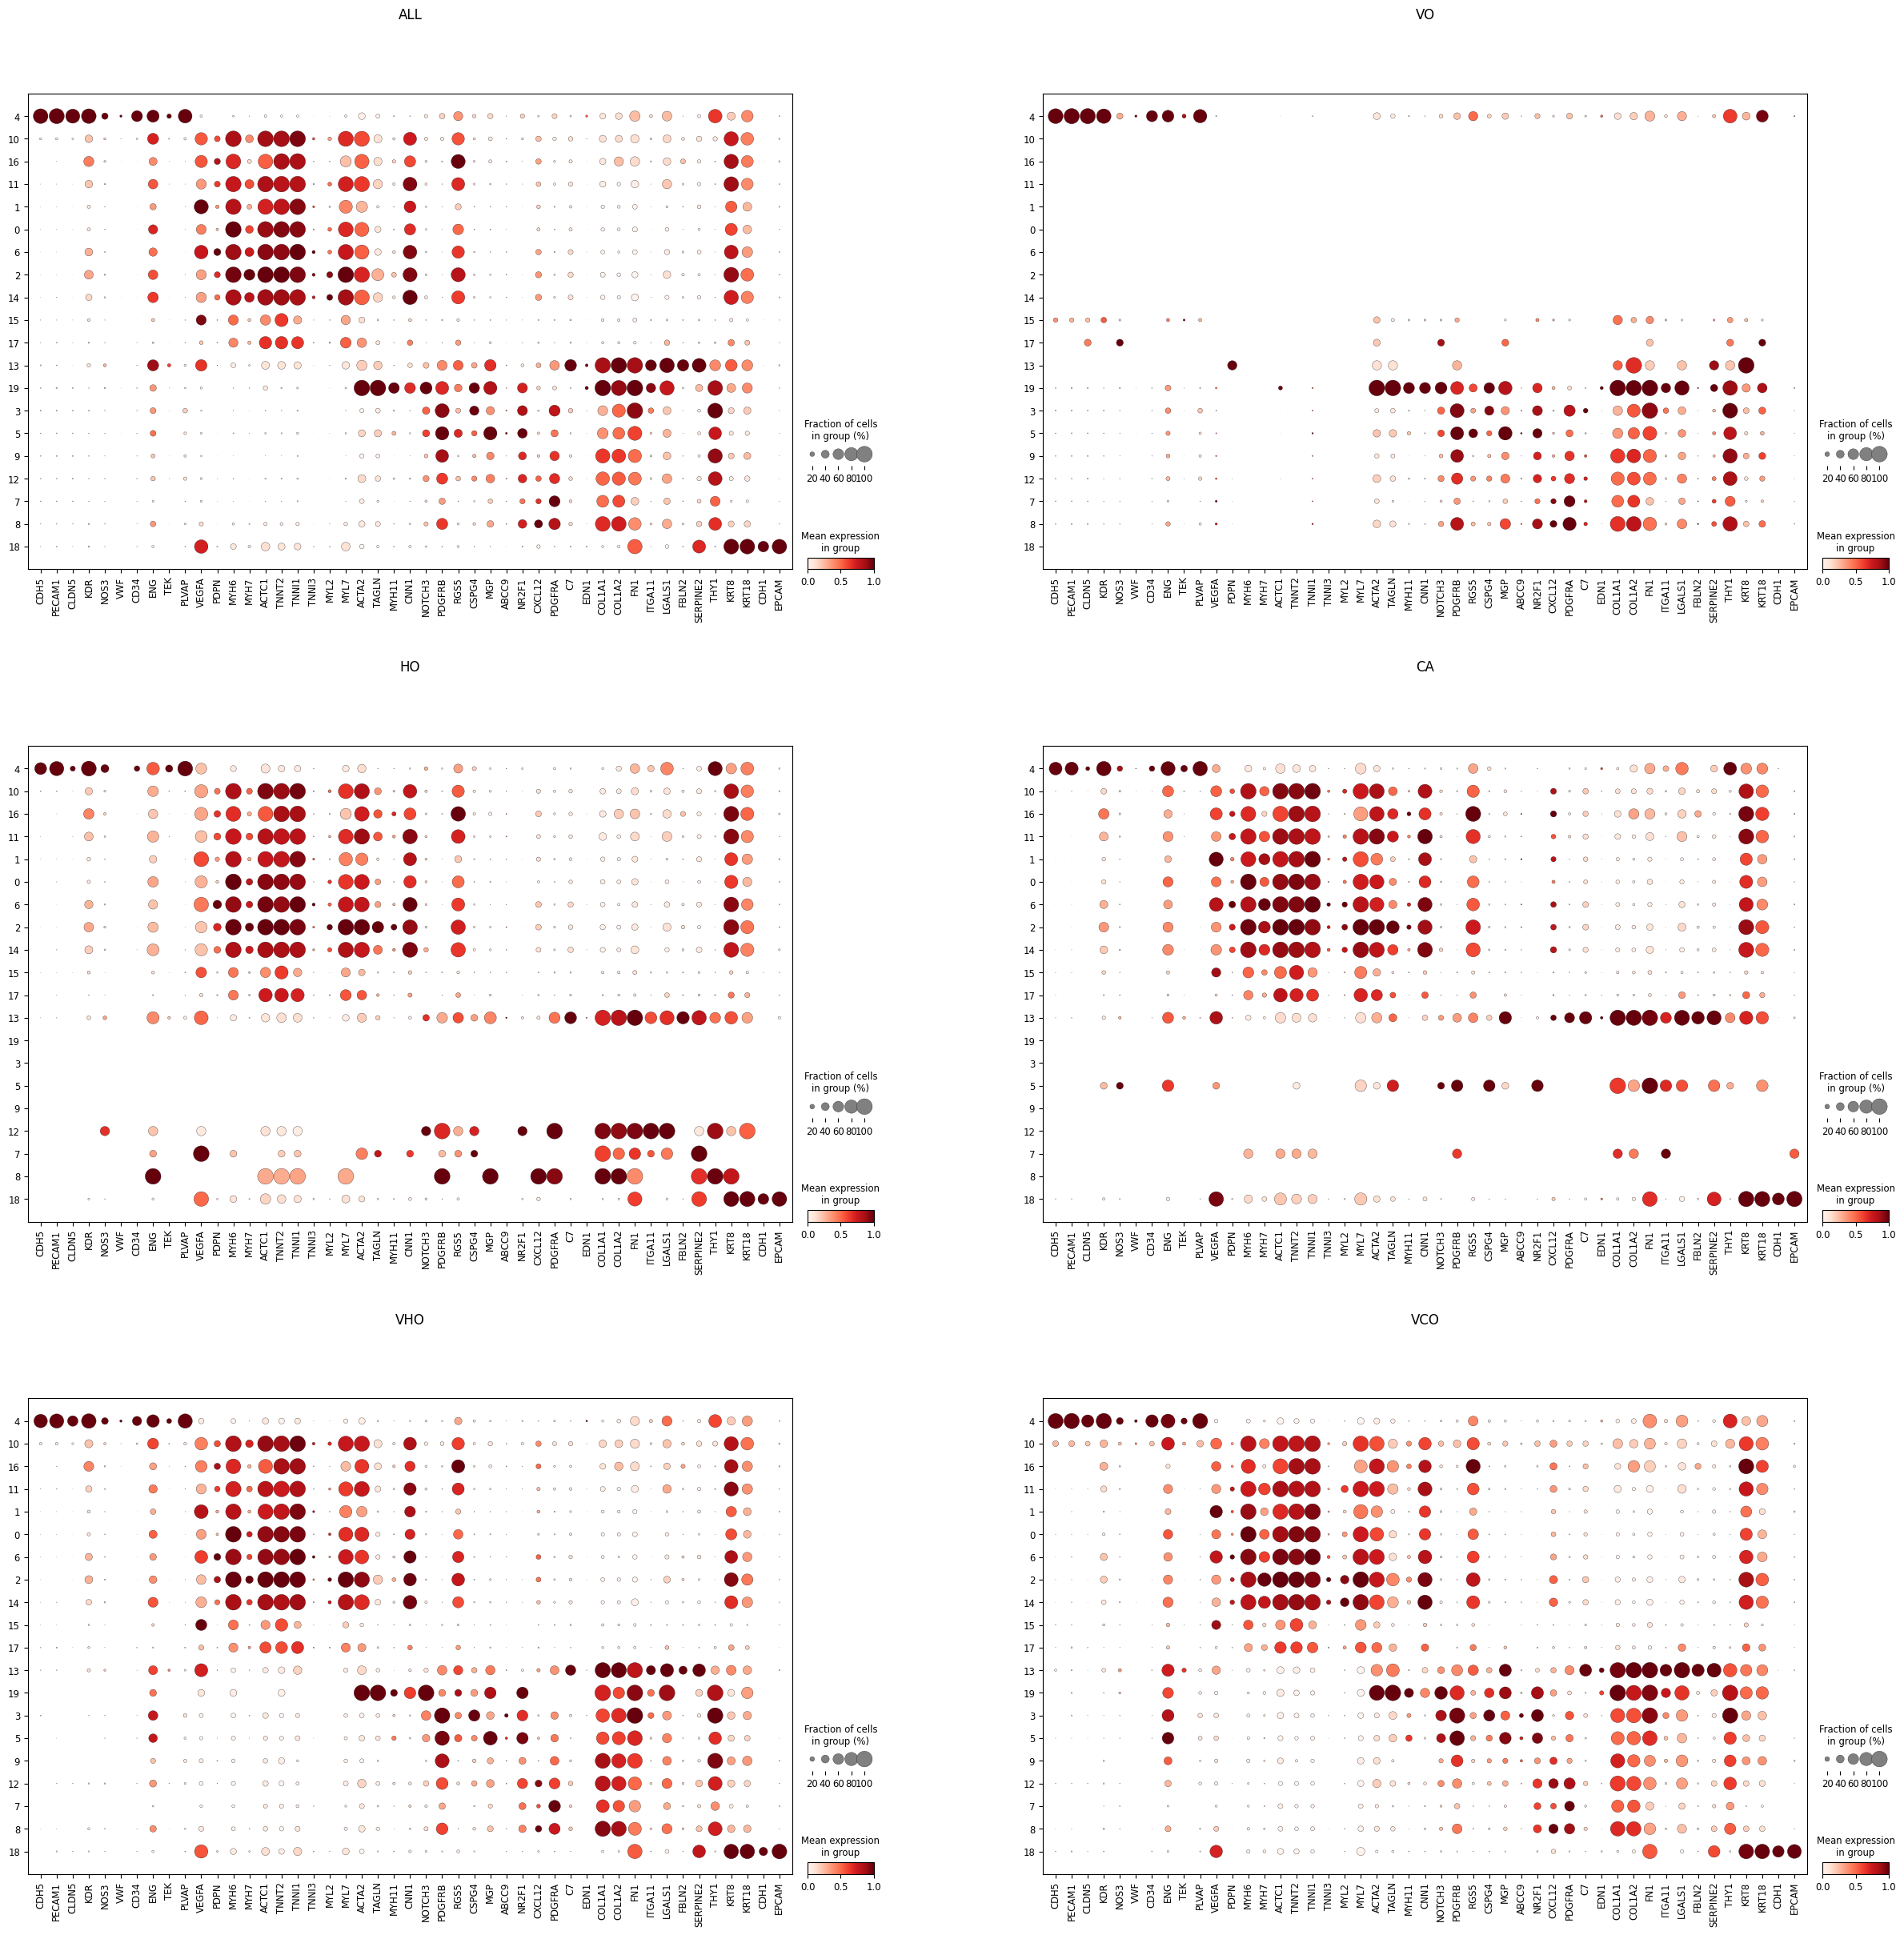

In [19]:
import warnings
warnings.filterwarnings("ignore")

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]
marker_dict_orderred = reorder_genes_2(marker_dict, adata_all)

cluster_order = [4, 10, 16, 11, 1, 0, 6, 2, 14, 15, 17, 13, 19, 3, 5, 9, 12, 7, 8, 18]

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    # sc.pl.dotplot(adata, marker_dict_orderred, groupby="leiden", standard_scale="var", ax=axs[i], title=sample, show=False)
    sc.pl.dotplot(adata, 
                  marker_dict, 
                  categories_order=cluster_order,
                  groupby="leiden", 
                  standard_scale="var", 
                  ax=axs[i], 
                  title=sample, 
                  show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.svg')
plt.show()

In [20]:
celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'MU',
    '4': 'EC',
    '5': 'MU',
    '6': 'CM',
    '7': 'MU',
    '8': 'MU',
    '9': 'MU',
    '10': 'CM',
    '11': 'CM',
    '12': 'MU',
    '13': 'MU',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'MU',
}

CM_order = [10, 16, 11, 1, 0, 6, 2, 14]
CM_color_min = (150/255, 230/255, 150/255)
CM_color_max = (15/255, 80/255, 15/255)

# MU_order = [13, 19, 3, 5, 9, 12, 7, 8]
MU_order = [19, 13, 8, 7, 12, 9, 5, 3]
MU_color_min = (240/255, 180/255, 20/255)
MU_color_max = (255/255, 250/255, 200/255)

def getColor(ld):
    ct = celltypes_dict[str(ld)]
    if ct in ("EP", "EC"):
        return colormap_cell_types[ct]
    elif ct == "CM":
        idx = CM_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(CM_color_min[i] + (CM_color_max[i]-CM_color_min[i]) / (len(CM_order)-1) * idx)
        return tuple(clr)
    elif ct == "MU":
        idx = MU_order.index(ld)
        clr = []
        for i in range(0, 3):
            clr.append(MU_color_min[i] + (MU_color_max[i]-MU_color_min[i]) / (len(MU_order)-1) * idx)
        return tuple(clr)
    else:
        clr = list(colormap_cell_types[ct])
        for i in range(0, len(clr)):
            np.random.seed(ld)
            clr[i] += (np.random.random() - 0.5) / 4
            if clr[i] > 1:
                clr[i] = 1
            elif clr[i] < 0:
                clr[i] = 0
        return tuple(clr)

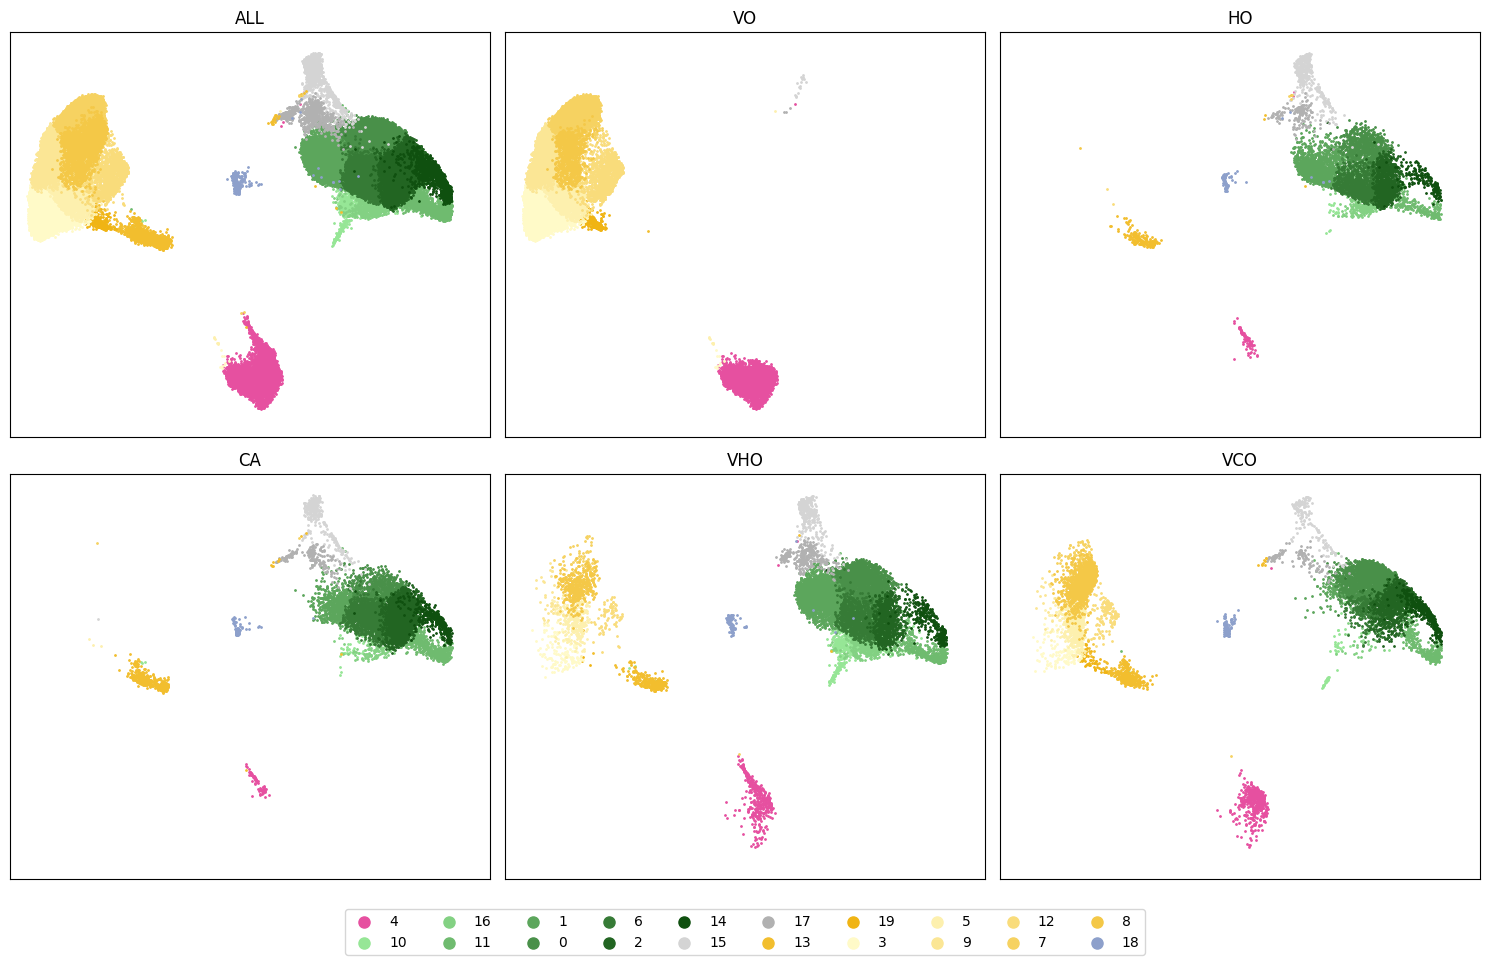

In [21]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    # for j, ld in enumerate(adata_all.obs["leiden"].unique().sort_values()):
    for j, ld in enumerate(cluster_order):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 1], 
            label=ld, 
            color=getColor(ld), 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

In [22]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

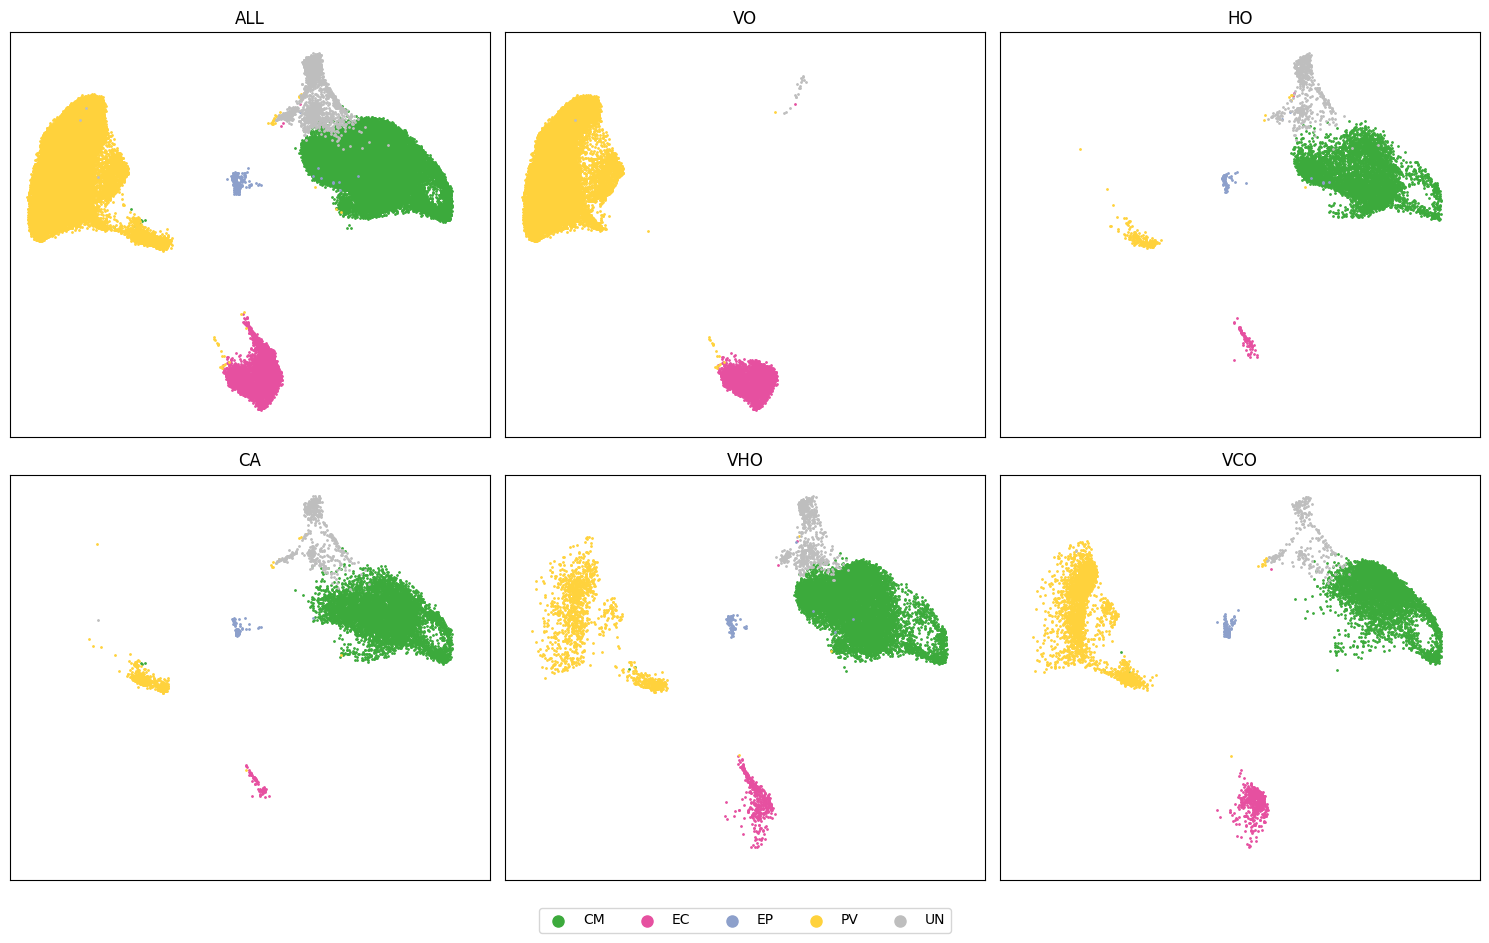

In [25]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, ct in enumerate(cell_types):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=cell_types_map[ct], 
            color=colormap_cell_types[ct], 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(cell_types_map[ct])
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/original_celltype.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/original_celltype.complete.svg', bbox_inches="tight")
plt.show()

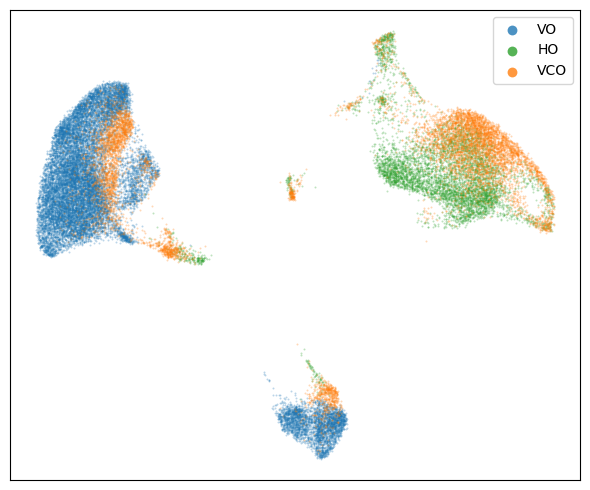

In [34]:
bc1 = "VO"
bc2 = "HO"
bc3 = "VCO"

adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, ax = plt.subplots(1, 1, figsize=(6,5))
colors = plt.get_cmap('tab10').colors

ax.scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=2, alpha=0.3, linewidths=0)
ax.scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=2, alpha=0.3, linewidths=0)
# ax.set_title(f"{bc1} + {bc2}")
leg = ax.legend(markerscale=5)
ax.set_xticks([])
ax.set_yticks([])

for lh in leg.legend_handles:
    lh.set_alpha(0.8)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

In [26]:
# bc1 = "VO"
# bc2 = "HO"
# bc3 = "VCO"

# adata_vo = adata_all[adata_all.obs['batch'] == bc1]
# adata_ho = adata_all[adata_all.obs['batch'] == bc2]
# adata_vco = adata_all[adata_all.obs['batch'] == bc3]

# fig, axs = plt.subplots(1, 2, figsize=(12,5))
# colors = plt.get_cmap('tab10').colors

# axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
# axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
# axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
# axs[0].set_title(f"{bc1} + {bc2}")
# axs[0].legend(markerscale=5)
# axs[0].set_xticks([])
# axs[0].set_yticks([])

# axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
# axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
# axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
# axs[1].set_title(bc3)
# axs[1].legend(markerscale=5)
# axs[1].set_xticks([])
# axs[1].set_yticks([])

# plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
# plt.show()

In [27]:
# bc1 = "VO"
# bc2 = "CA"
# bc3 = "VCO"

# adata_vo = adata_all[adata_all.obs['batch'] == bc1]
# adata_ho = adata_all[adata_all.obs['batch'] == bc2]
# adata_vco = adata_all[adata_all.obs['batch'] == bc3]

# fig, axs = plt.subplots(1, 2, figsize=(12,5))
# colors = plt.get_cmap('tab10').colors

# axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
# axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
# axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
# axs[0].set_title(f"{bc1} + {bc2}")
# axs[0].legend(markerscale=5)
# axs[0].set_xticks([])
# axs[0].set_yticks([])

# axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
# axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
# axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
# axs[1].set_title(bc3)
# axs[1].legend(markerscale=5)
# axs[1].set_xticks([])
# axs[1].set_yticks([])

# plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
# plt.show()

In [28]:
# bc1 = "VO"
# bc2 = "HO"
# bc3 = "VHO"

# adata_vo = adata_all[adata_all.obs['batch'] == bc1]
# adata_ho = adata_all[adata_all.obs['batch'] == bc2]
# adata_vco = adata_all[adata_all.obs['batch'] == bc3]

# fig, axs = plt.subplots(1, 2, figsize=(12,5))
# colors = plt.get_cmap('tab10').colors

# axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
# axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
# axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
# axs[0].set_title(f"{bc1} + {bc2}")
# axs[0].legend(markerscale=5)
# axs[0].set_xticks([])
# axs[0].set_yticks([])

# axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
# axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
# axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
# axs[1].set_title(bc3)
# axs[1].legend(markerscale=5)
# axs[1].set_xticks([])
# axs[1].set_yticks([])

# plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
# plt.show()

# 2. Celltype split and recluster

## 2.1 CM

In [32]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

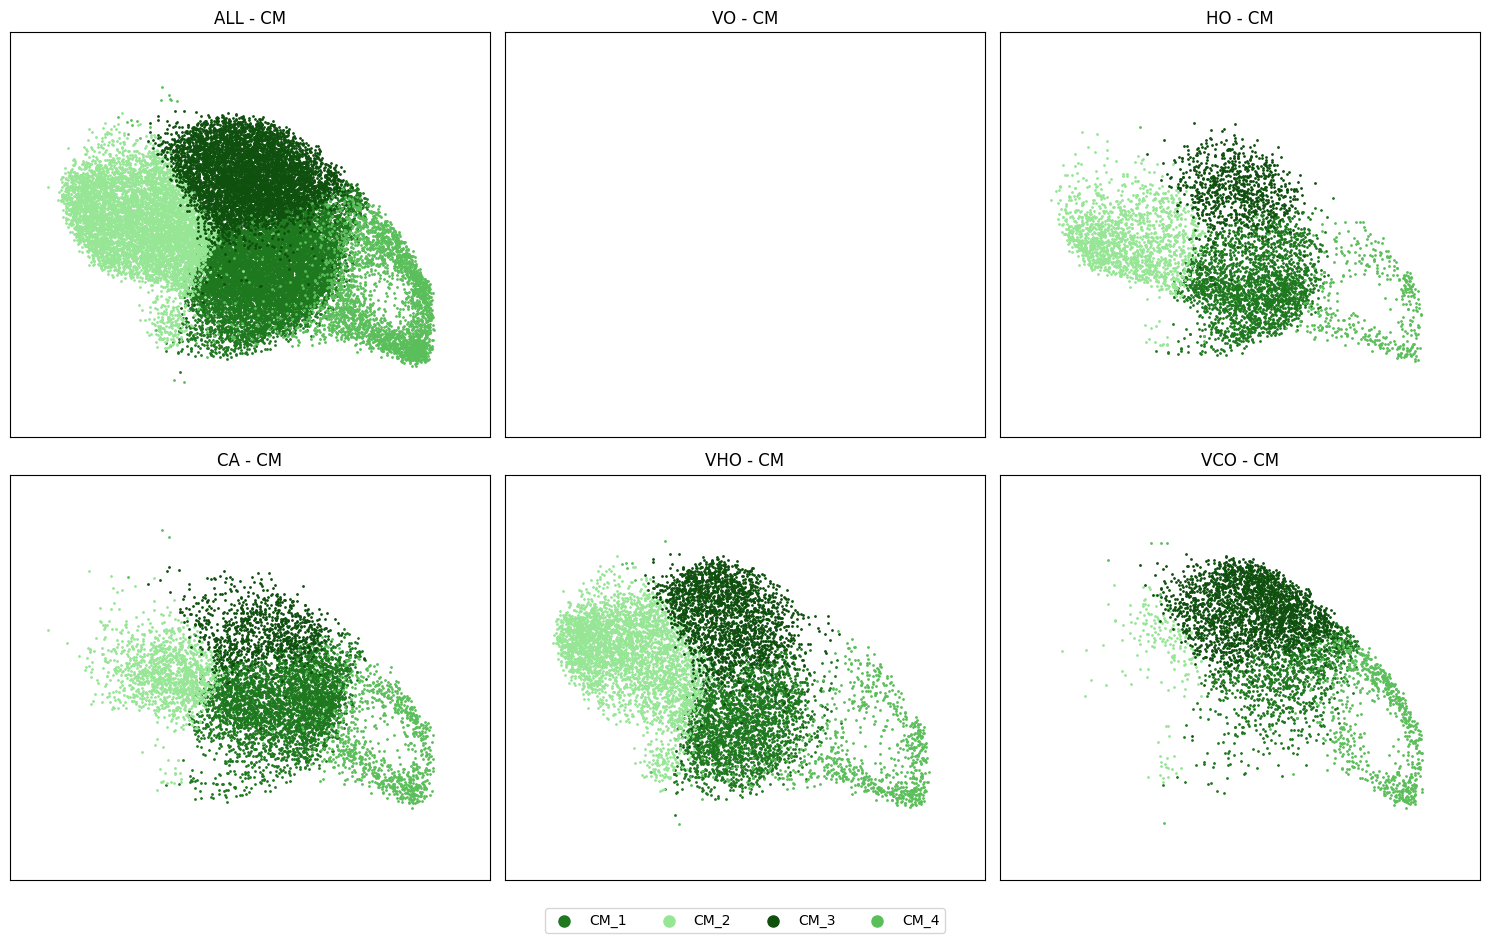

In [33]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([7, 20])
    ax.set_ylim([5, 15])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

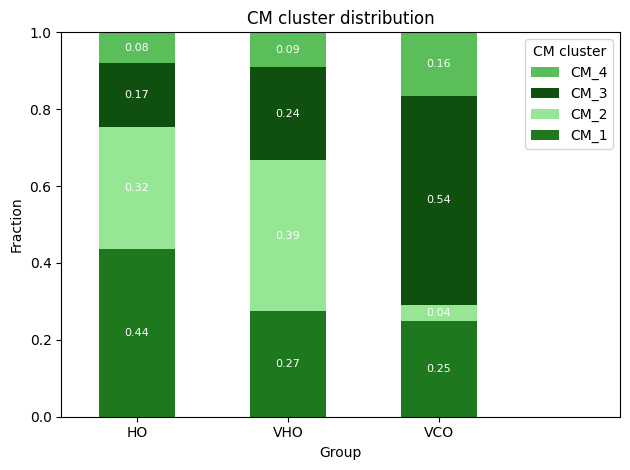

In [34]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'CA' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

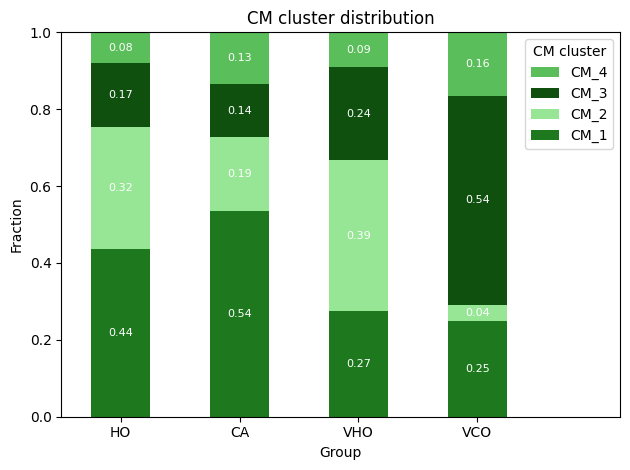

In [35]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


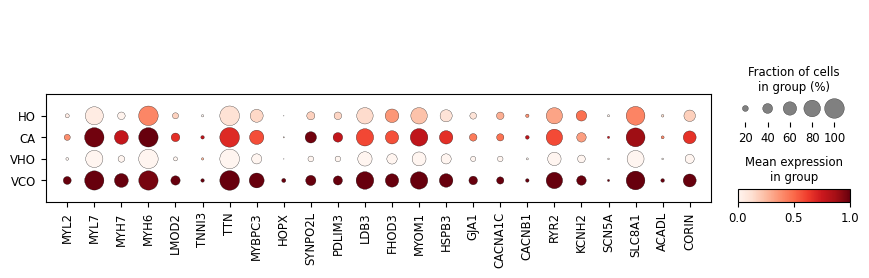

In [36]:
# marker_dict = ['TNNI3', 'MYL2', 'MYL7', 'MYH7', 'MYH6', 'TTN', 'RYR2', 'SLC8A1', 'KCNH2', 'SCN5A', 'LMOD2', 'GJA1', 'ACADL']
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 'ACADL', 'CORIN']
categories_order = ["HO", 'CA', 'VHO', 'VCO']

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

In [25]:
# sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False)
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
# plt.show()

## 2.2 EC

In [7]:
ct = "EC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

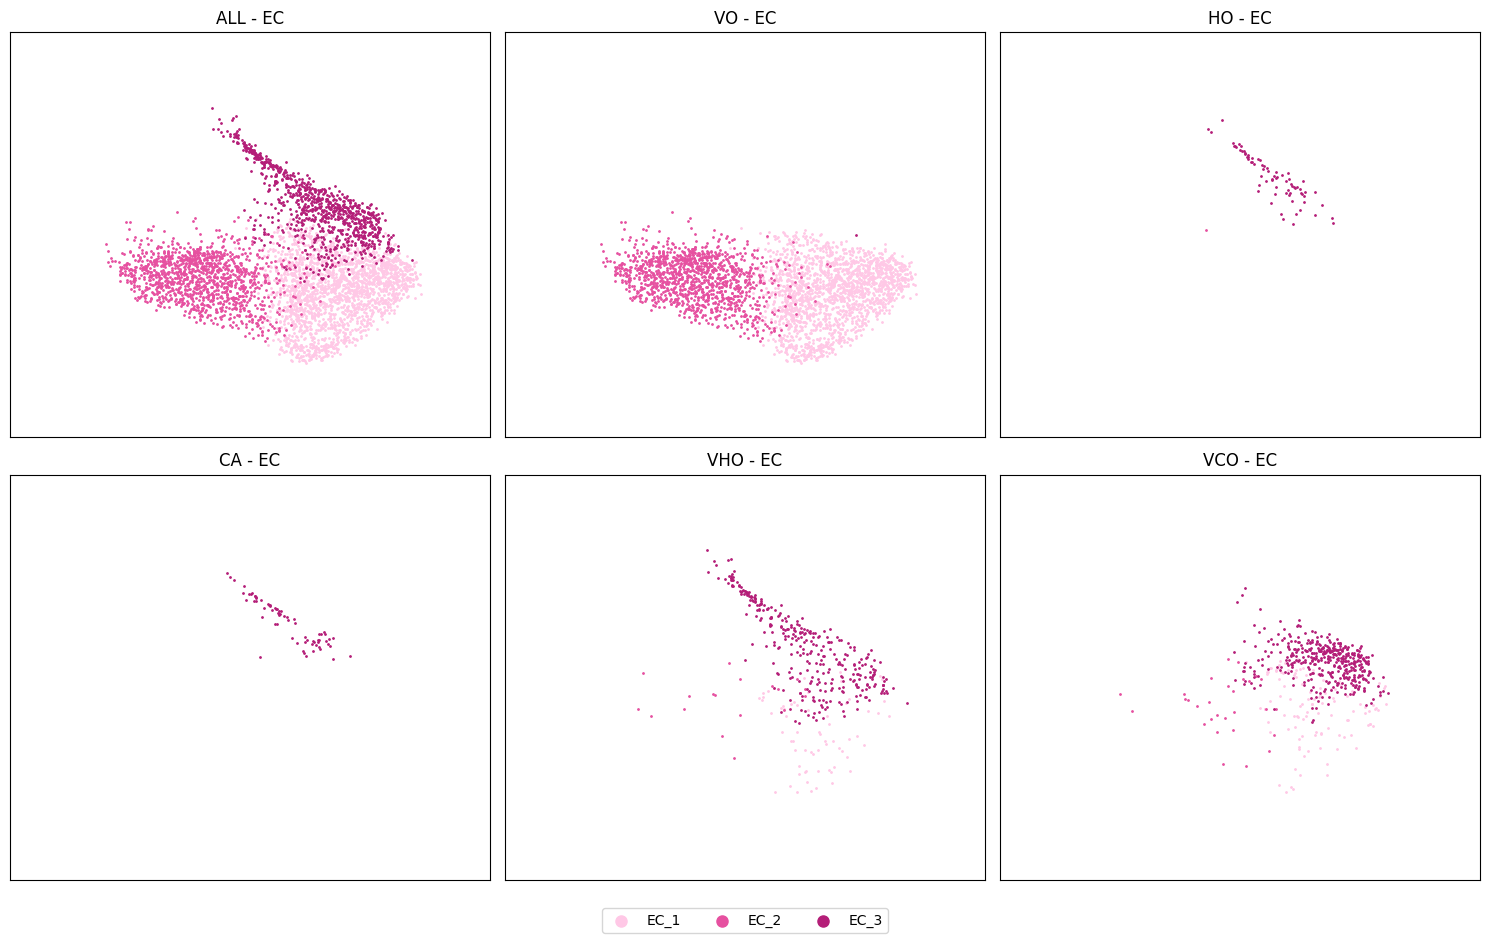

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

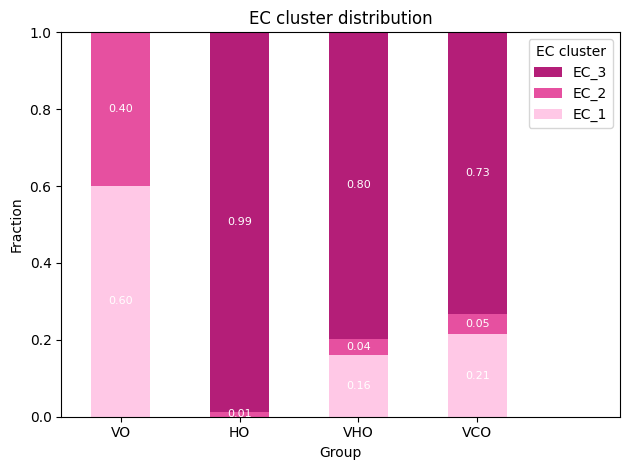

In [9]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'CA':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

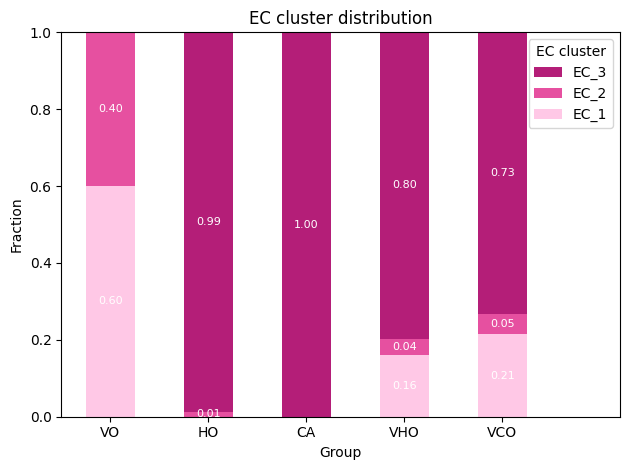

In [10]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


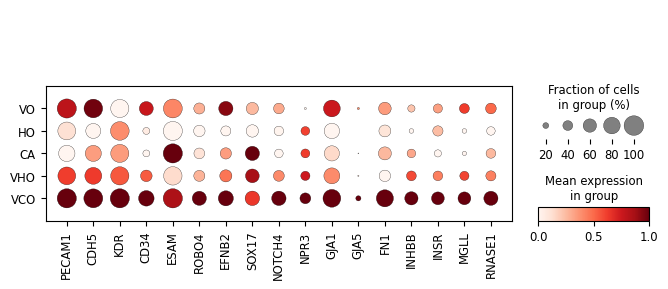

In [11]:
# marker_dict = ['CDH5', 'VWF', 'CD34', 'PECAM1', 'EFNB2', 'KDR', 'NPR3', 'AQP1', 'EDN1', 'GJA1', 'GJA5']
# marker_dict = [
#     "PECAM1", "CDH5", "VWF", "KDR", "CD34", "CLDN5", "ESAM", "TEK",
#     "ROBO4", "EMCN", "EFNB2", "SOX17", "DLL4", "NOTCH4", "HEY1", "HEY2",
#     "GJA5", "GJA1", "KLF2", "KLF4", "NPR3", "FN1", "INHBB", "INSR",
#     "MGLL", "RNASE1", "ICAM1", "VCAM1", "SELE", "CXCL8", "CCL2", "PTGS2"
# ]
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1']

categories_order = ["VO", "HO", 'CA', 'VHO', 'VCO']

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


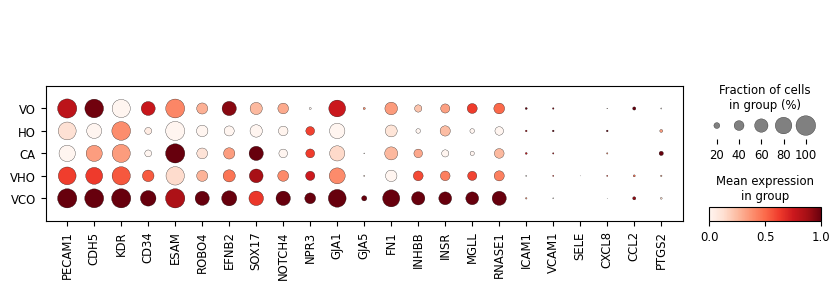

In [13]:
# marker_dict = ['CDH5', 'VWF', 'CD34', 'PECAM1', 'EFNB2', 'KDR', 'NPR3', 'AQP1', 'EDN1', 'GJA1', 'GJA5']
# marker_dict = [
#     "PECAM1", "CDH5", "VWF", "KDR", "CD34", "CLDN5", "ESAM", "TEK",
#     "ROBO4", "EMCN", "EFNB2", "SOX17", "DLL4", "NOTCH4", "HEY1", "HEY2",
#     "GJA5", "GJA1", "KLF2", "KLF4", "NPR3", "FN1", "INHBB", "INSR",
#     "MGLL", "RNASE1", "ICAM1", "VCAM1", "SELE", "CXCL8", "CCL2", "PTGS2"
# ]
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1', 'ICAM1', 'VCAM1', 'SELE', 'CXCL8', 'CCL2','PTGS2']

categories_order = ["VO", "HO", 'CA', 'VHO', 'VCO']

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.full.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.full.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


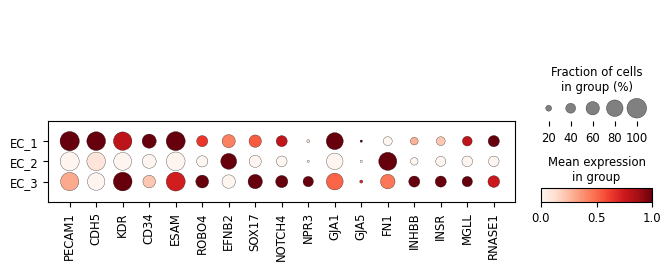

In [12]:
sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.3 PV

In [53]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

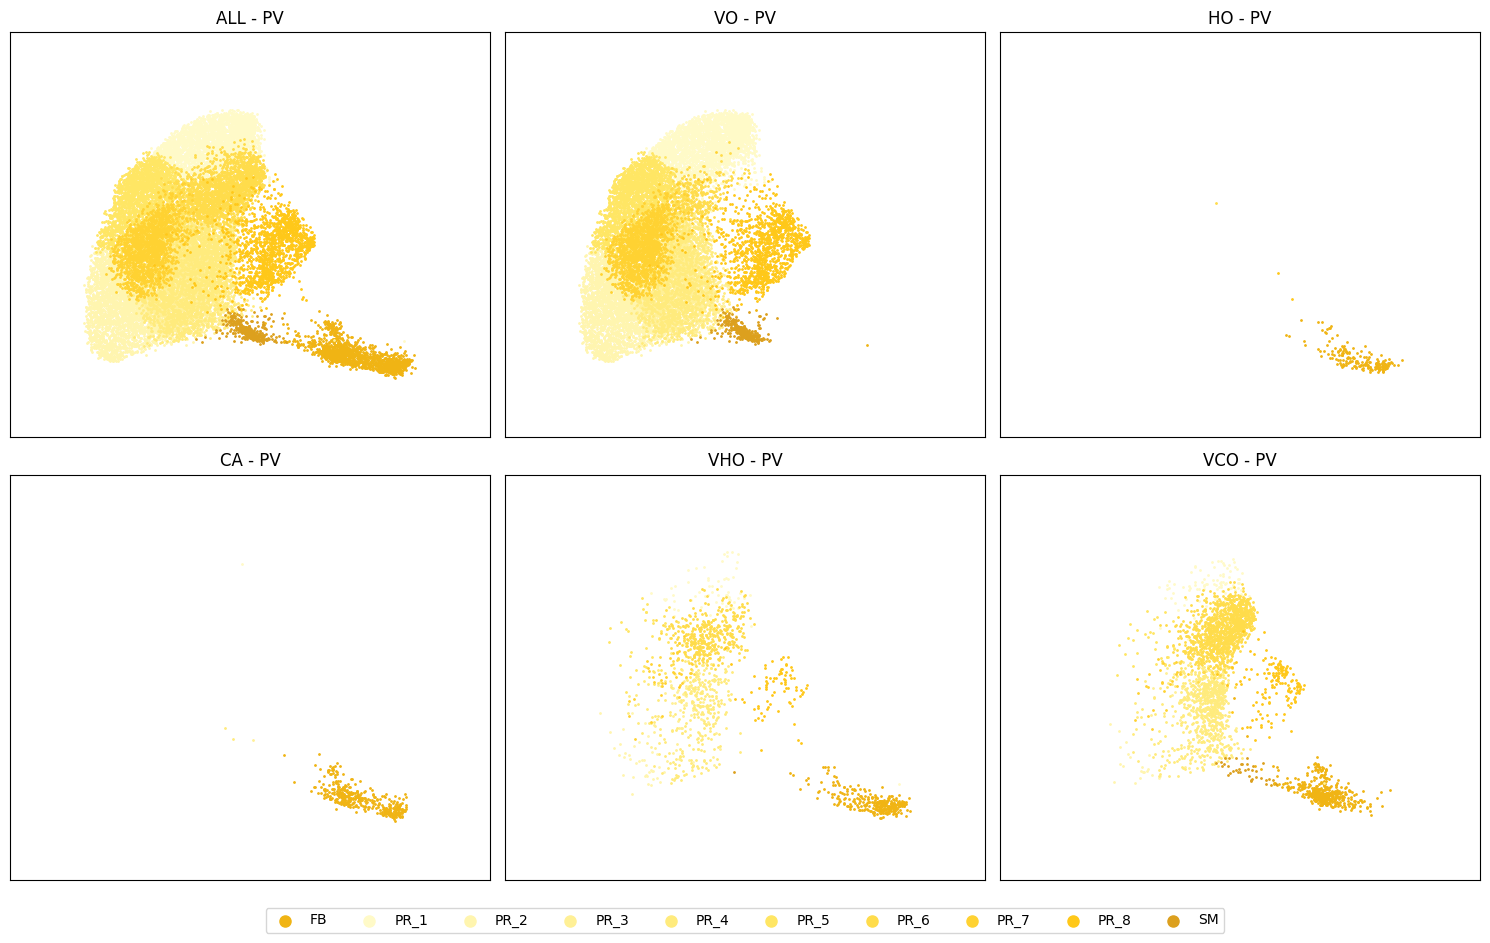

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([-12, 2])
    ax.set_ylim([3, 17])
    ax.set_title(f"{sample} - {cell_types_map[ct]}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=12,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{cell_types_map[ct]}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_leiden.{cell_types_map[ct]}.svg', bbox_inches="tight")
plt.show()

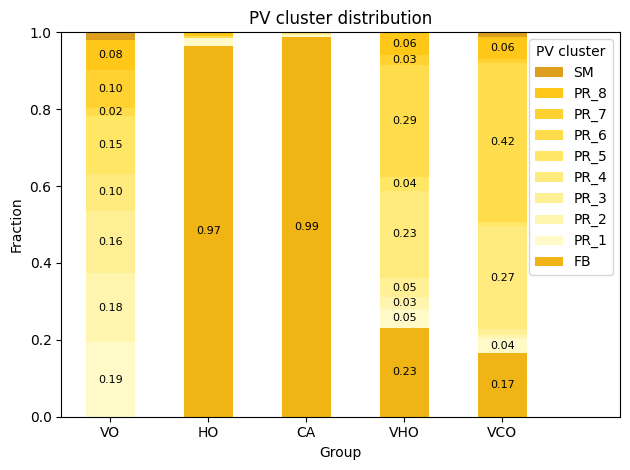

In [55]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{cell_types_map[ct]} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{cell_types_map[ct]} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{cell_types_map[ct]}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{cell_types_map[ct]}.svg', bbox_inches="tight")
plt.show()

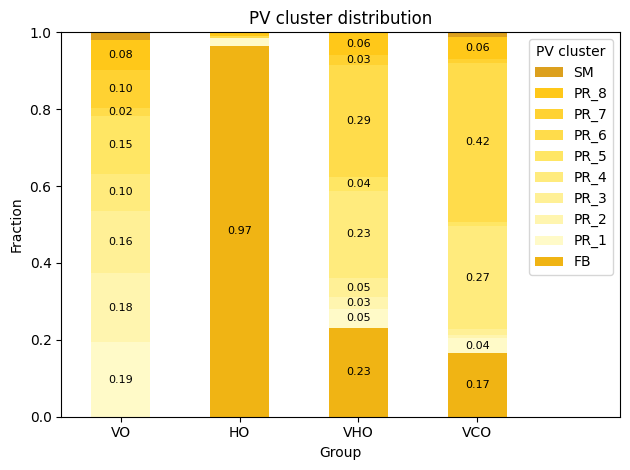

In [56]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == "CA":
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{cell_types_map[ct]} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{cell_types_map[ct]} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{cell_types_map[ct]}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{cell_types_map[ct]}.svg', bbox_inches="tight")
plt.show()

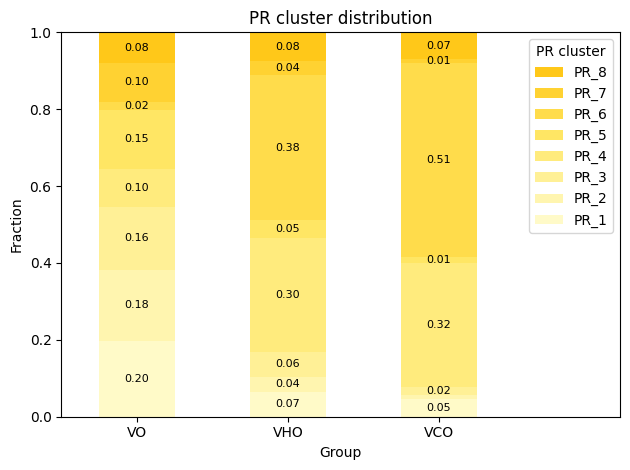

In [57]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'HO' or sample == 'CA':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.drop('FB', axis=1)
df = df.drop('SM', axis=1)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"PR cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'PR cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden.PR.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden.PR.svg', bbox_inches="tight")
plt.show()

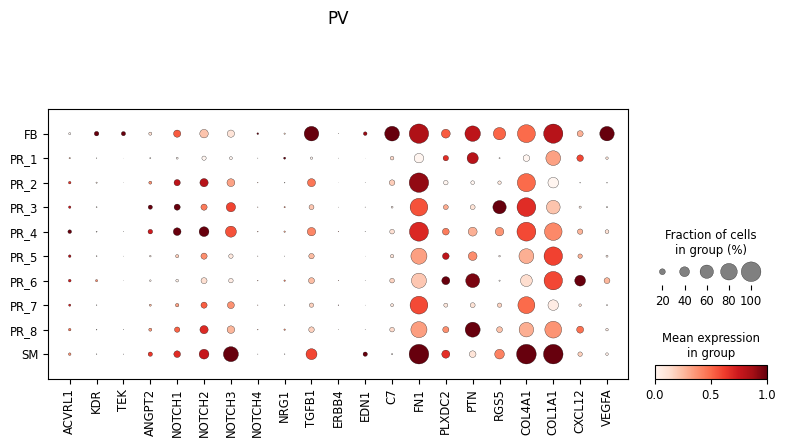

In [58]:
marker_dict = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
               'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
               'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
               'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", title=cell_types_map[ct], show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{cell_types_map[ct]}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{cell_types_map[ct]}.svg', bbox_inches="tight")
plt.show()

In [46]:
# ct = "MU"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
# adata = adata[adata.obs['cpdb_group'] == 'PR']

# marker_str = "RSPO3, ANGPTL1, SPARCL1, MEOX2, TCF21, SOSTDC1, NEFL, NEFM, CLDN5, CDH5, MMP13, CEMIP, RUNX2, TNFSF11, HPGD, CCR1, CCRL2, GLIS3, A2M, IL6, CD36, GJA4, TPPP3, CAV1, OLFML2A, OLFML2B, FABP4, FRY,  MYH11, ACTA2, TAGLN, RGS5, ABCC9, MCAM, MFAP4, GJA4, MKI67, TOP2A, CCNB1, CCNB2, CDC20, CDK1, ASPM, AURKB, PLK1, PCNA,  RSPO3, SPARCL1, CXCL12, NRXN1, SLITRK5, KCNN2, GATA3, CDH7, NCAM2, FLRT3, SYT4, CD36, OLFML2A, OLFML2B, MMP9, PDGFA, MCAM, NRXN1, FLRT3, CXCL12,  RSPO3, SPARCL1, ANGPTL1, KCNN2, NRXN1, SYT4, NEFL, MYH11, FN1, COL4A1"
# marker_dict = marker_str.replace(" ", "").split(",")
# marker_dict_order = reorder_genes(marker_dict, adata)

# sc.pl.dotplot(adata, marker_dict_order, groupby="cell_type_subcluster", standard_scale="var", title="Pericyte-like cells", show=False)
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.PR.old.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.PR.old.svg', bbox_inches="tight")
# plt.show()

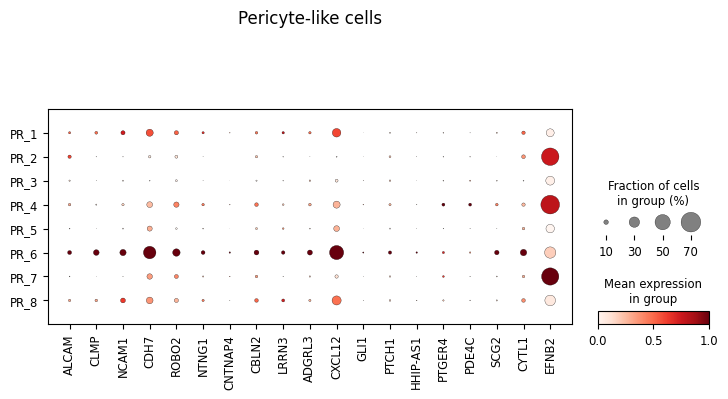

In [47]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
adata = adata[adata.obs['cpdb_group'] == 'PR']

marker_dict = [
    "ALCAM", "CLMP", "NCAM1", "CDH7", "ROBO2", "NTNG1", "CNTNAP4",
    "CBLN2", "LRRN3", "ADGRL3", "CXCL12", "GLI1", "PTCH1",
    "HHIP-AS1", "PTGER4", "PDE4C", "SCG2", "CYTL1", "EFNB2"
]

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", title="Pericyte-like cells", show=False)
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.PR.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.PR.svg', bbox_inches="tight")
plt.show()

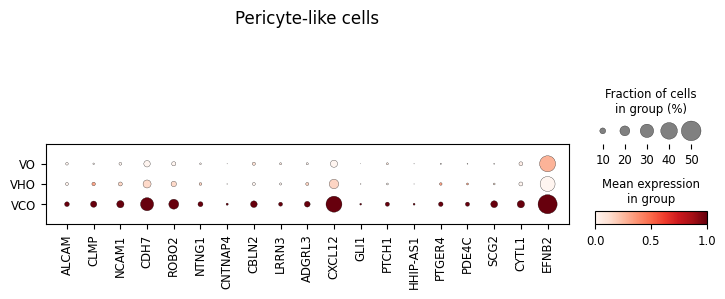

In [48]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
adata = adata[adata.obs['cpdb_group'] == 'PR']
adata = adata[adata.obs['batch'] != 'HO']
adata = adata[adata.obs['batch'] != 'CA']

marker_dict = [
    "ALCAM", "CLMP", "NCAM1", "CDH7", "ROBO2", "NTNG1", "CNTNAP4",
    "CBLN2", "LRRN3", "ADGRL3", "CXCL12", "GLI1", "PTCH1",
    "HHIP-AS1", "PTGER4", "PDE4C", "SCG2", "CYTL1", "EFNB2"
]

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title="Pericyte-like cells", show=False, categories_order=["VO", "VHO", "VCO"])
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.PR.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.PR.svg', bbox_inches="tight")
plt.show()

## 2.4 Recollect

In [49]:
adata_all = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/ALL.h5ad')

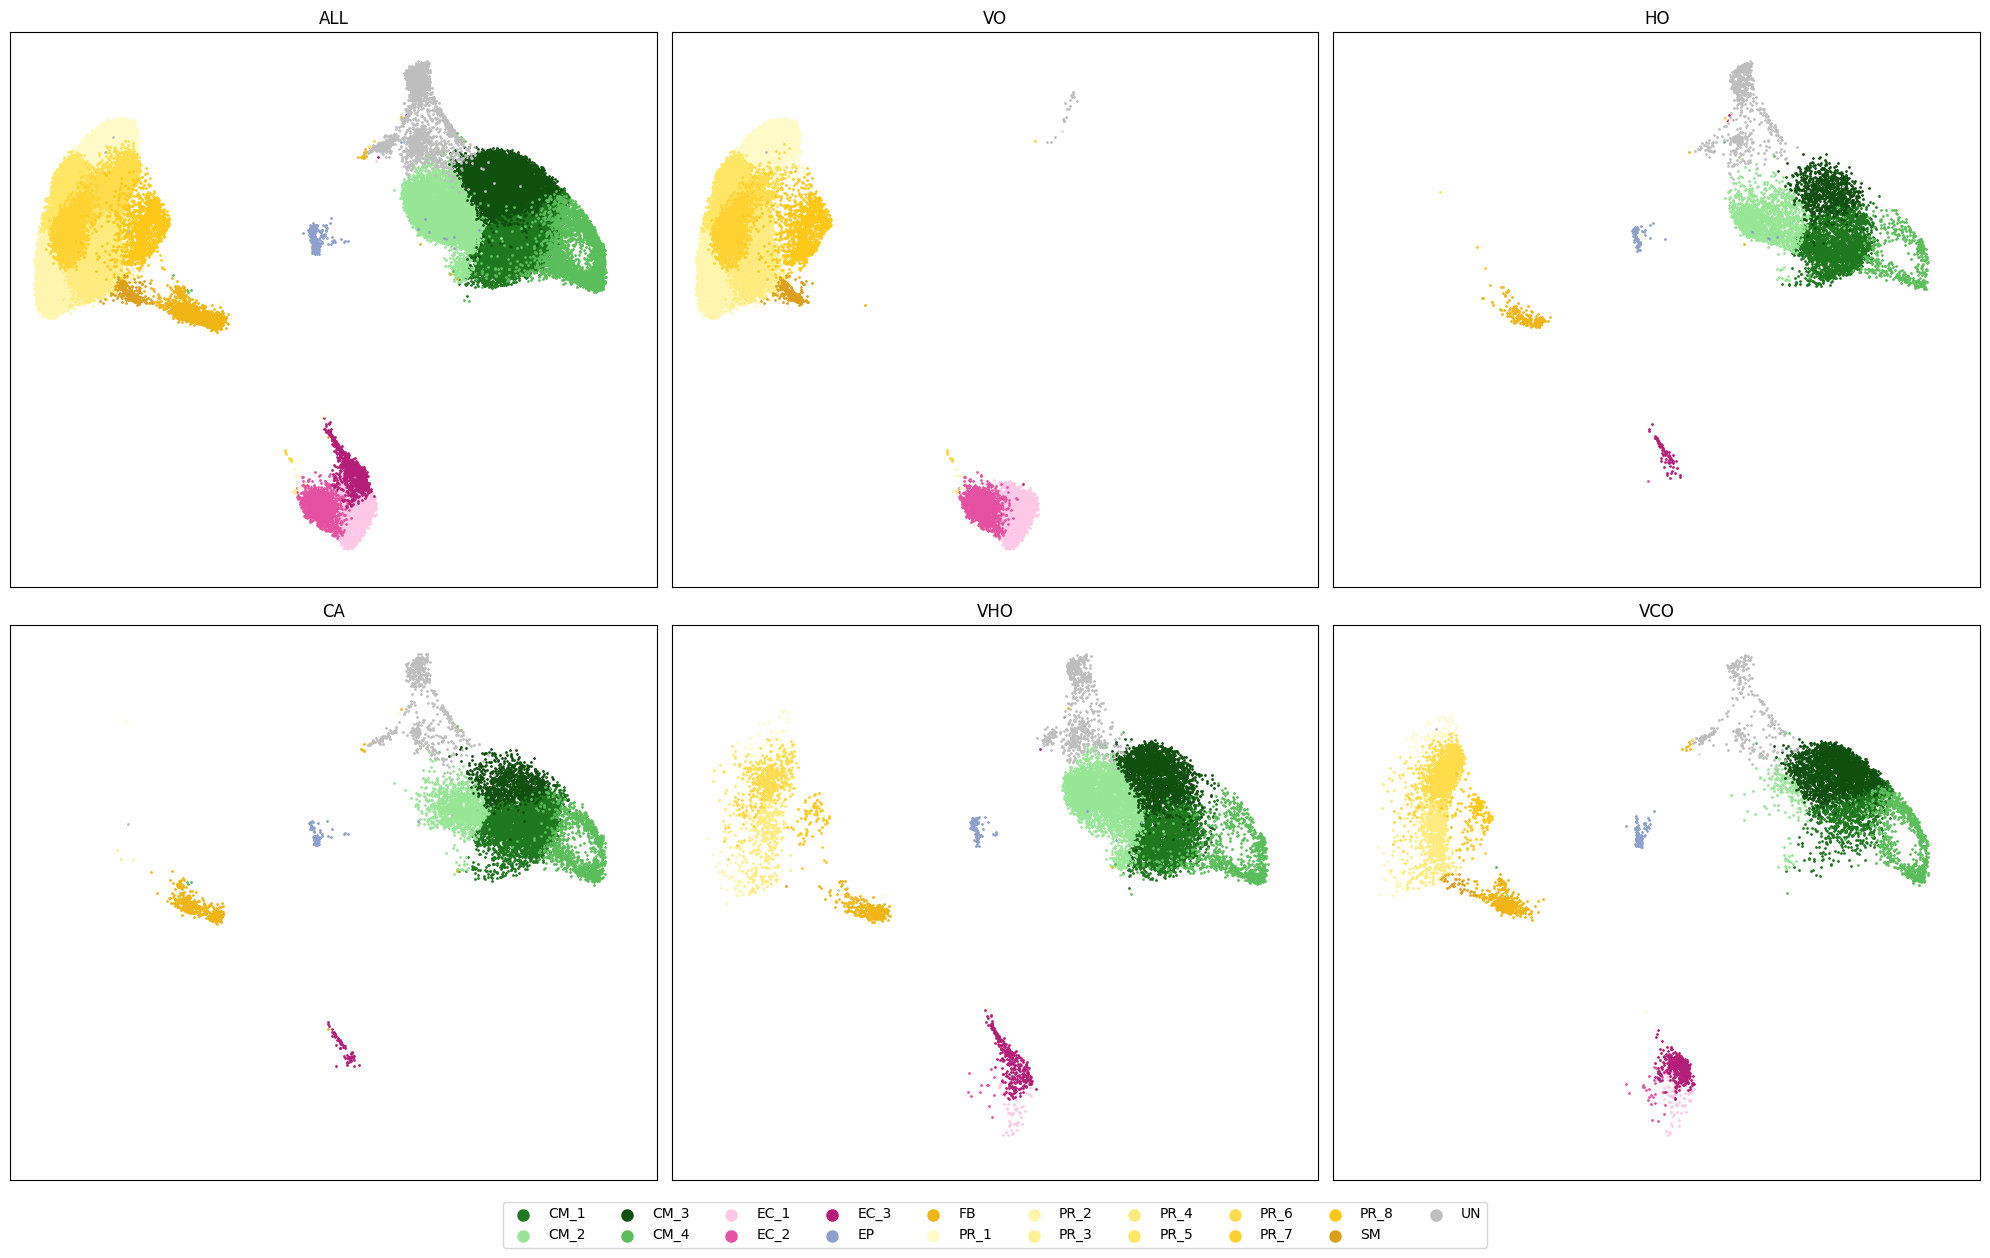

In [50]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cell_type_subcluster"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colormap_subclusters[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/secondary_label.complete.svg', bbox_inches="tight")
plt.show()

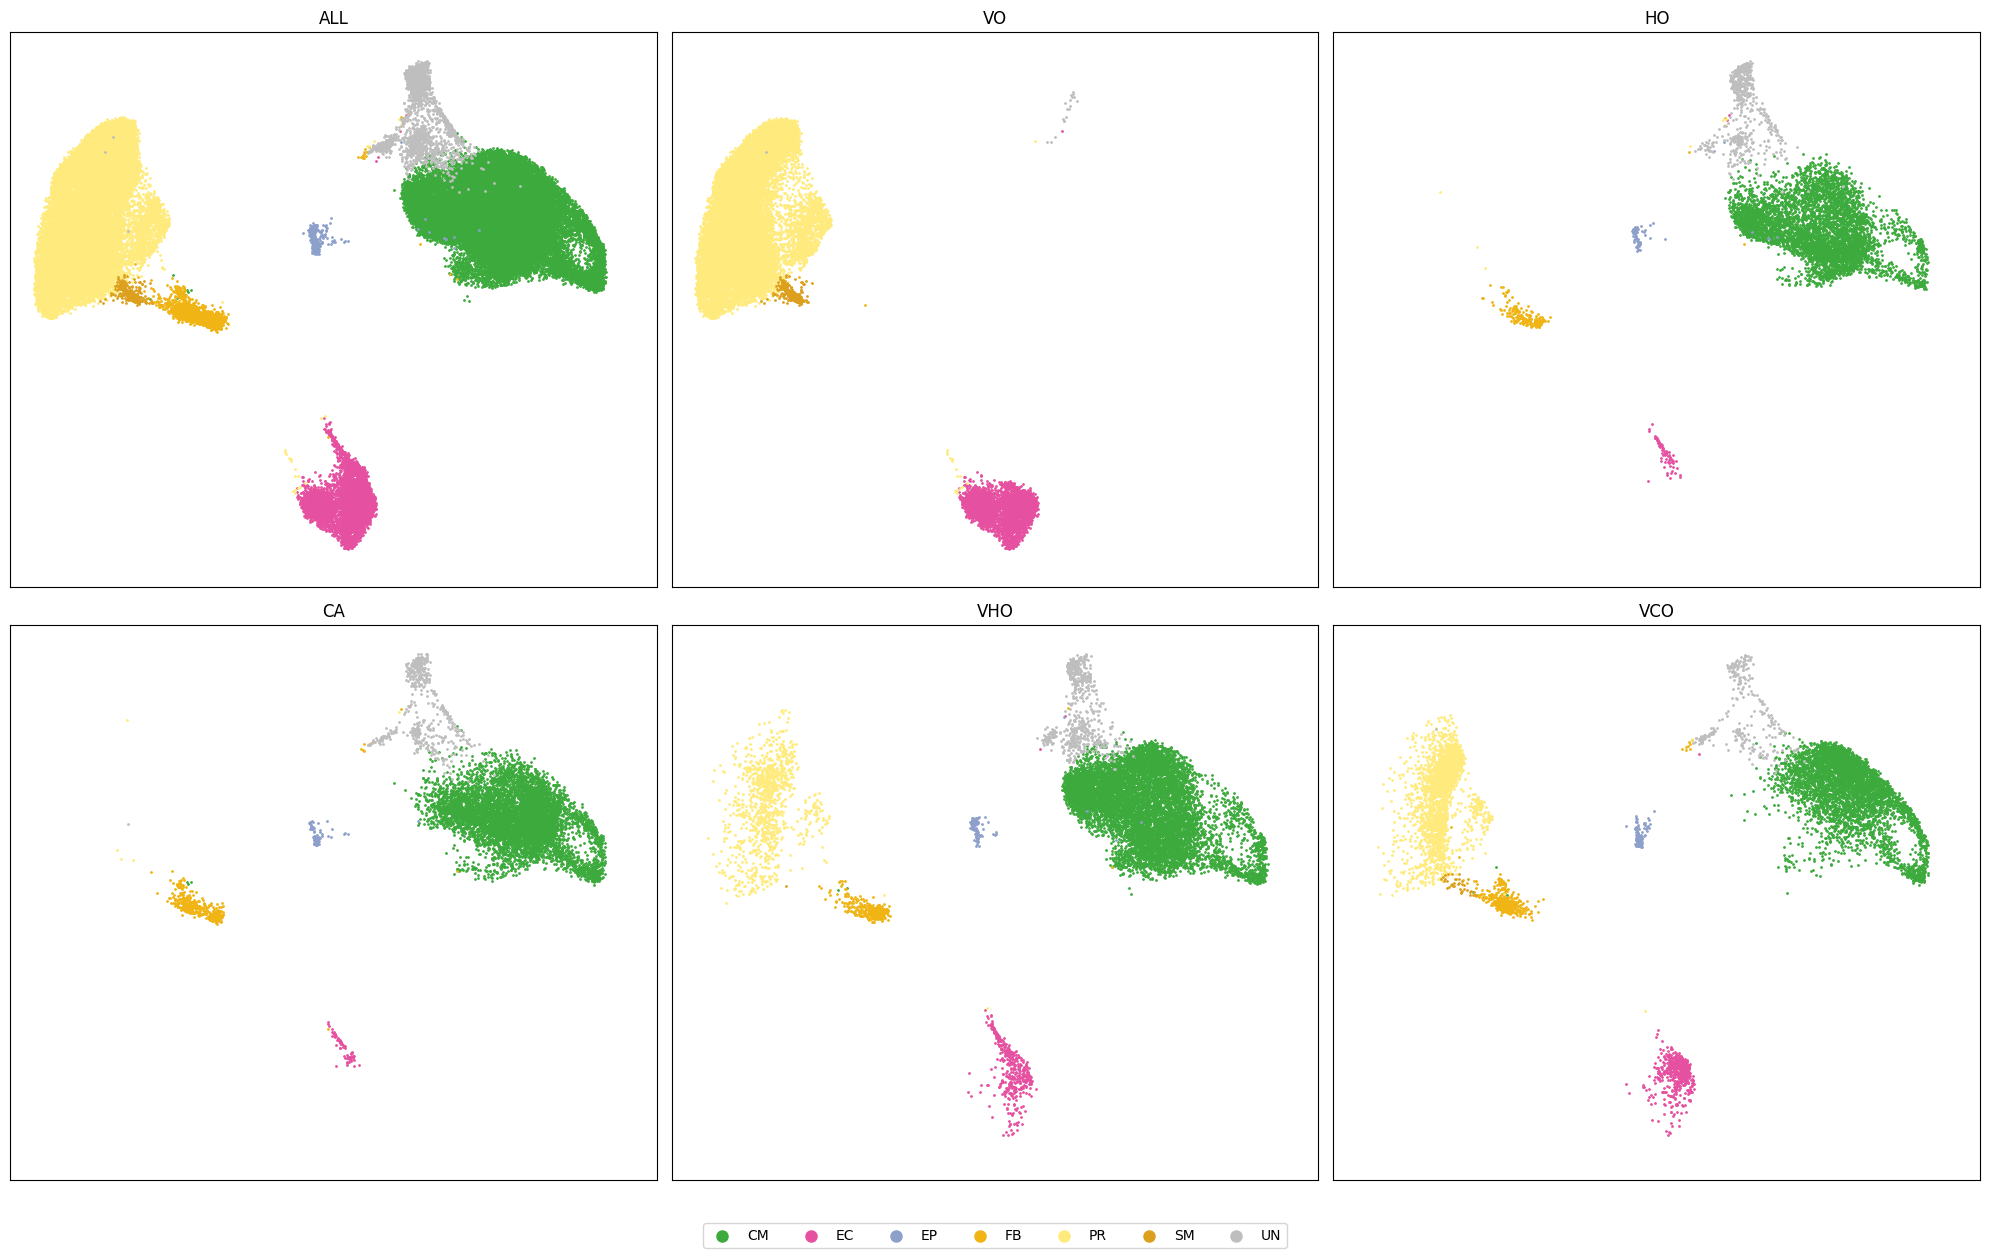

In [52]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):

    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    
    for j, cts in enumerate(adata_all.obs["cpdb_group"].unique().sort_values()):
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 1], 
            label=cts, 
            color=colormap_cpdb[cts], 
            s=1)
                
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)

    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/UMAP/cpdb_group.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/UMAP/cpdb_group.complete.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

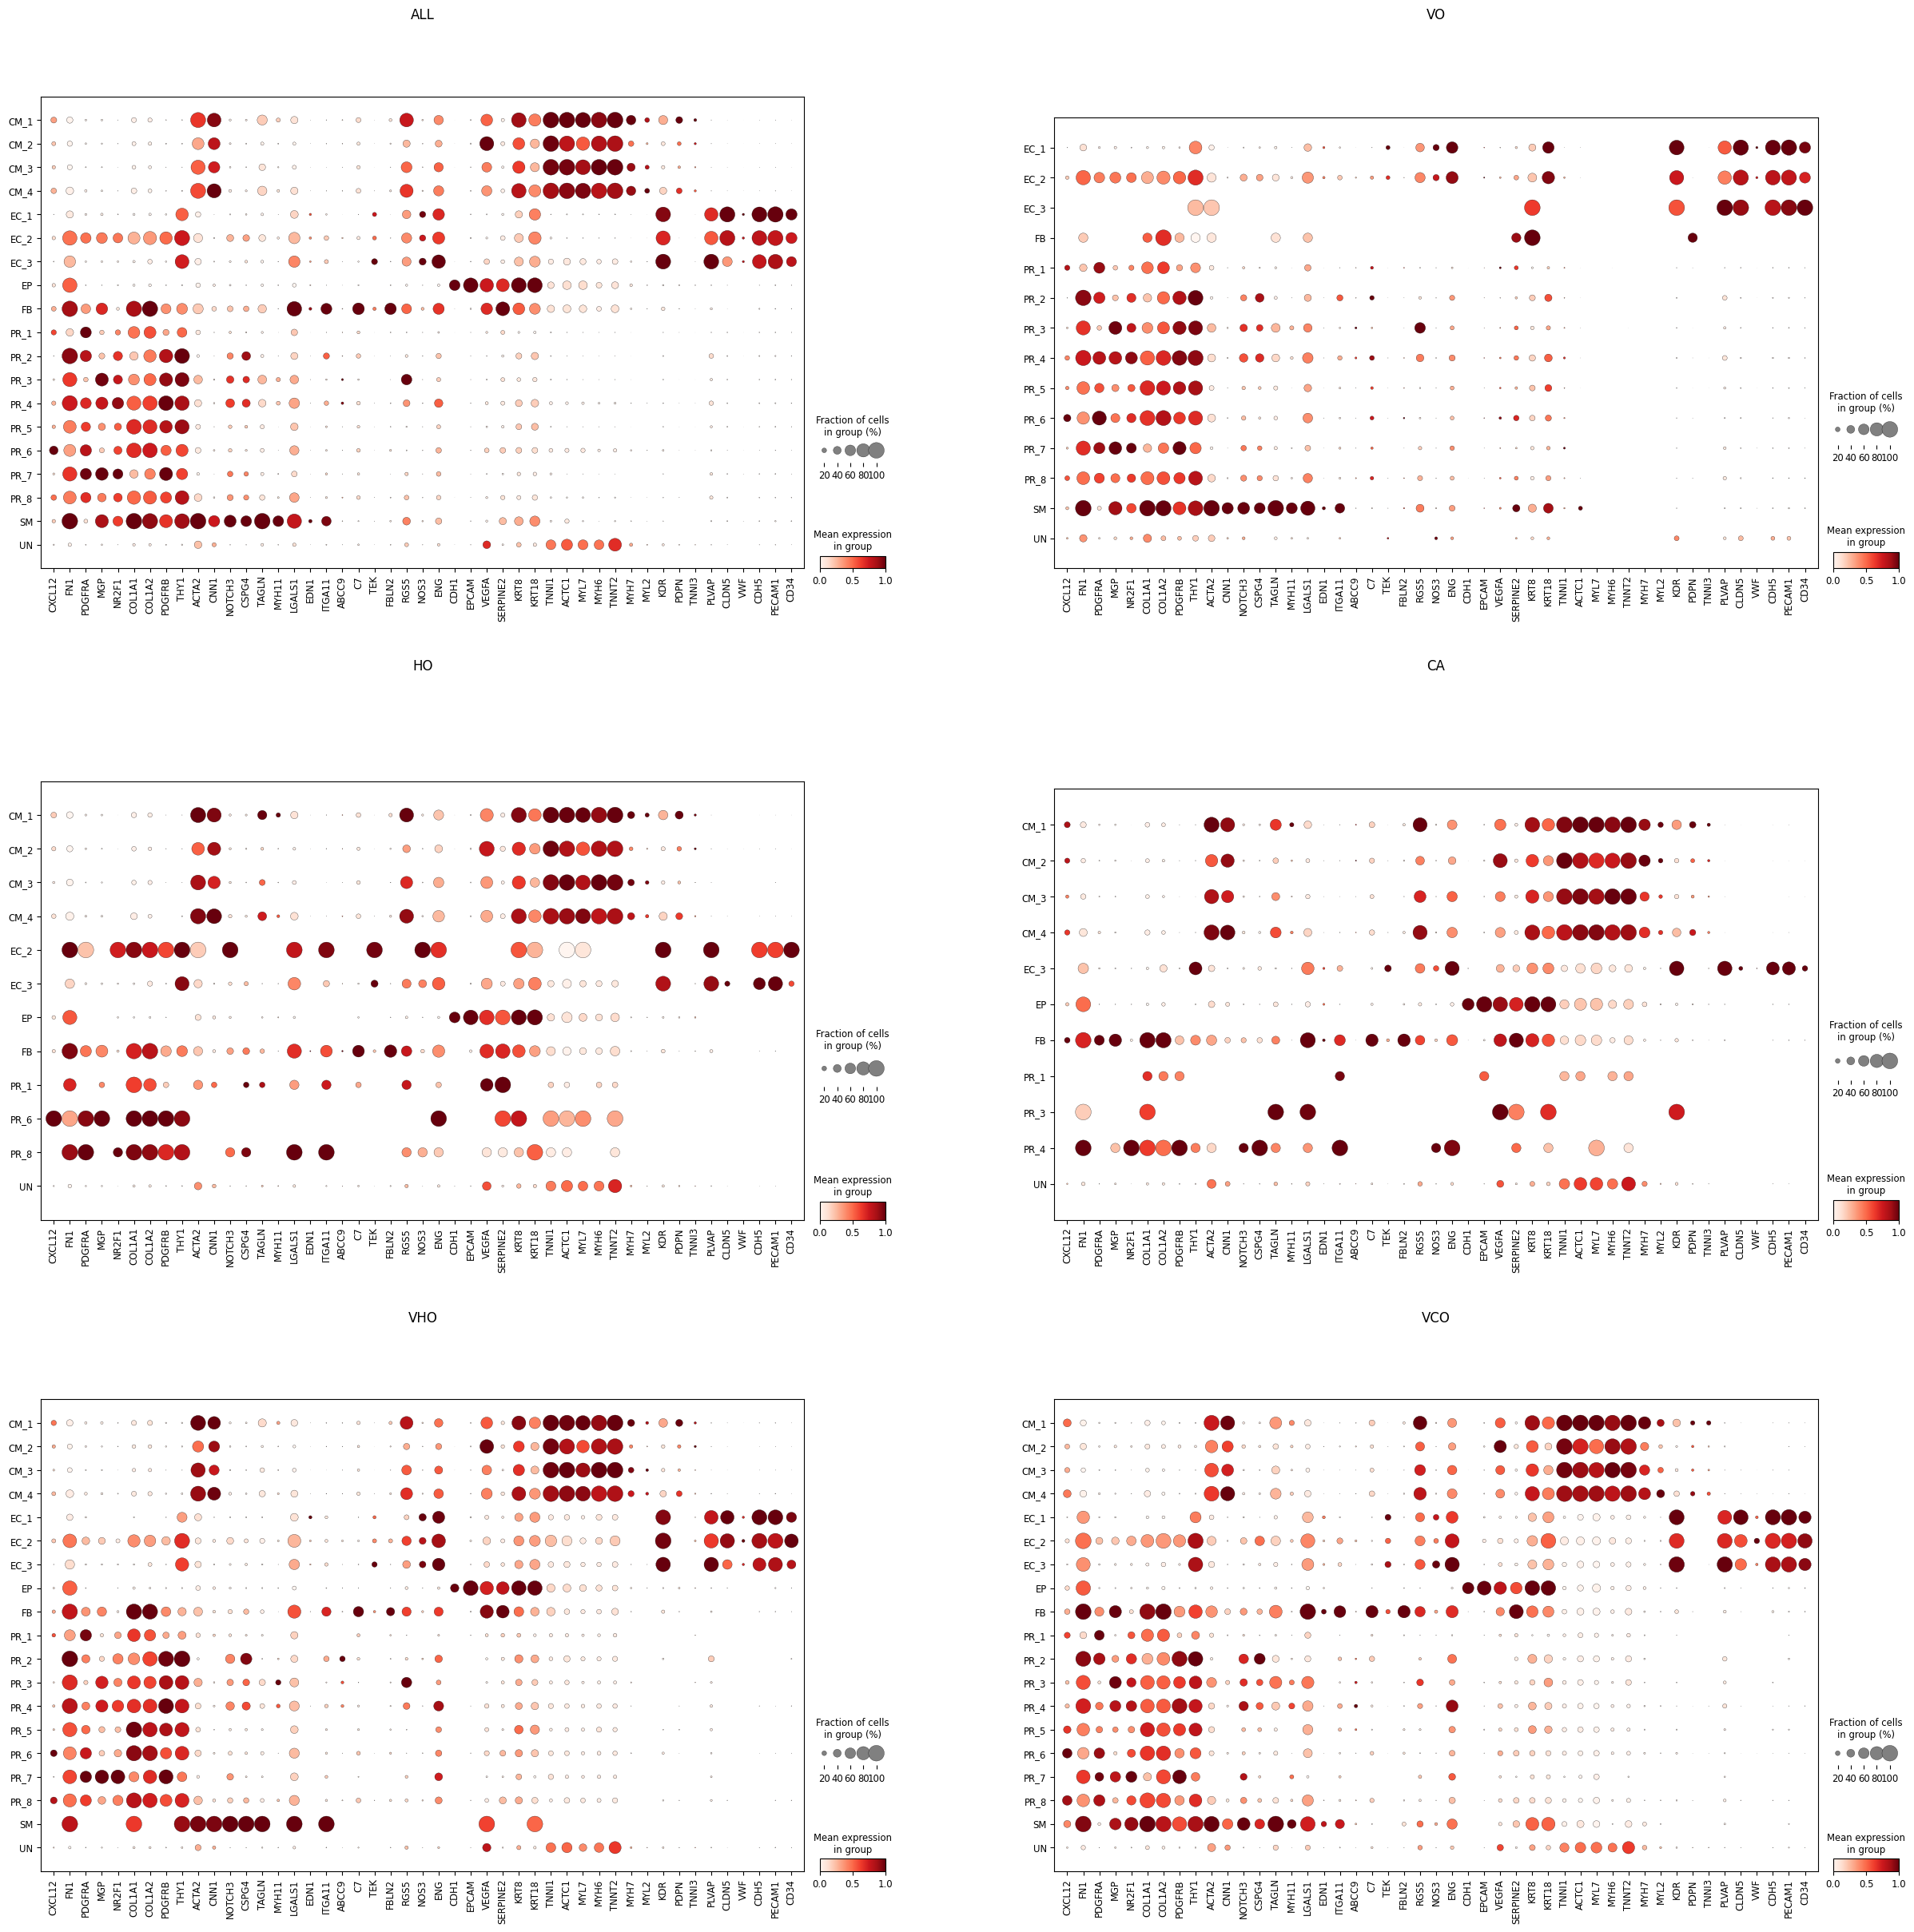

In [30]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]
marker_dict_orderred = reorder_genes_2(marker_dict, adata_all)

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == sample]
    sc.pl.dotplot(adata, marker_dict_orderred, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample, show=False)
    
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/secondary_label.complete.svg')
plt.show()

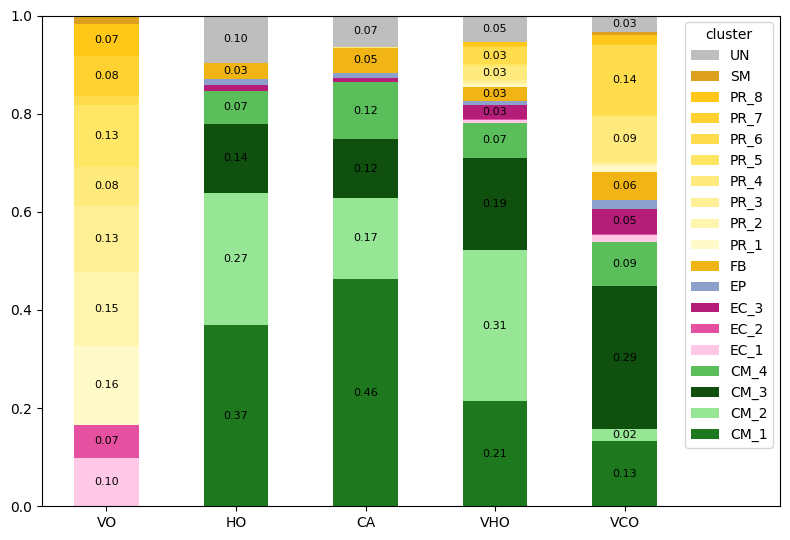

In [106]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
# ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
# plt.title("Celltype subcluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_label_wCA.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_label_wCA.complete.svg', bbox_inches="tight")
plt.show()

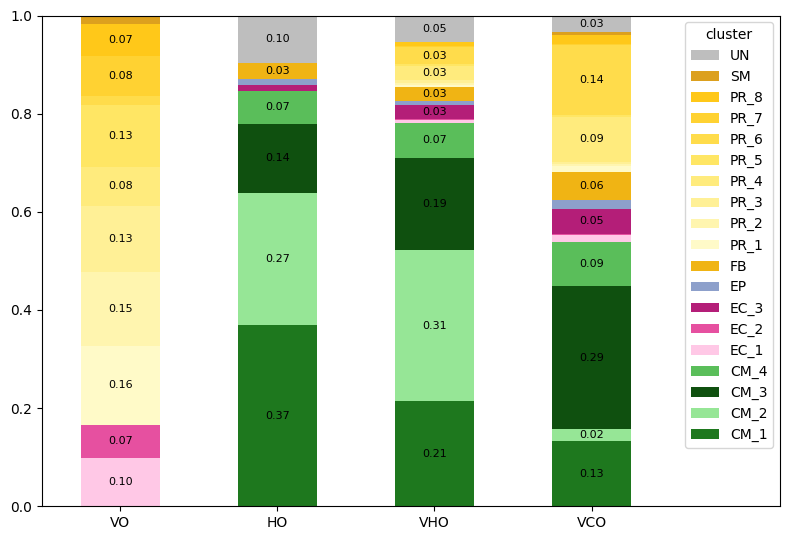

In [107]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL" or sample == "CA":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
# ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
# plt.title("Celltype subcluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_label_woCA.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_label_woCA.complete.svg', bbox_inches="tight")
plt.show()

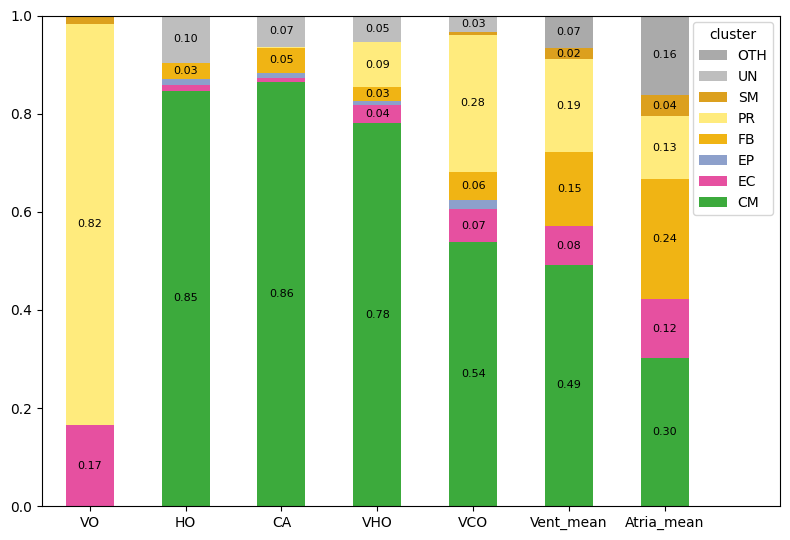

In [108]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cpdb_group'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Vent_mean"] = df["VCO"].copy()
df["Atria_mean"] = df["Vent_mean"].copy()

df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["FB", "Vent_mean"] = 15.1
df.loc["PR", "Vent_mean"] = 19
df.loc["SM", "Vent_mean"] = 2.2
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["FB", "Atria_mean"] = 24.3
df.loc["PR", "Atria_mean"] = 12.9
df.loc["SM", "Atria_mean"] = 4.2
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, color=[colormap_cpdb[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 7.2))
plt.xticks(rotation=0)
# plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/cpdb_group_wCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/cpdb_group_wCA.complete_extra.svg', bbox_inches="tight")
plt.show()

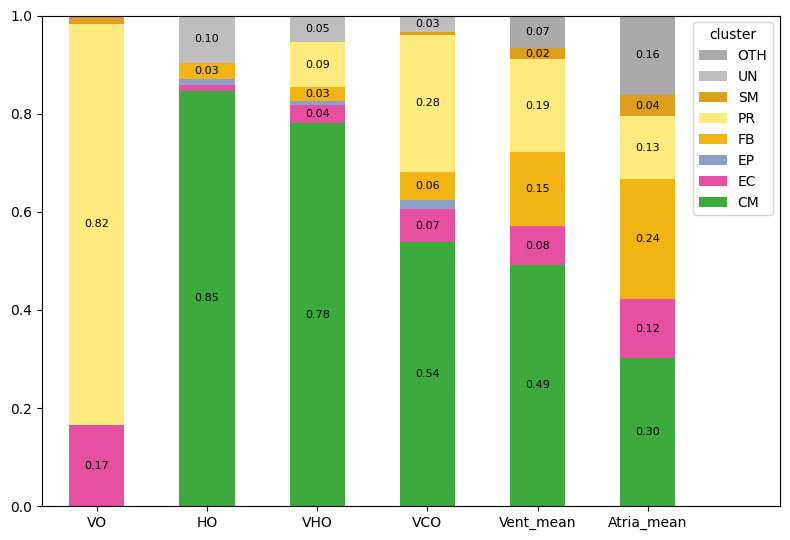

In [109]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL" or sample == "CA":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cpdb_group'].value_counts())
    res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Vent_mean"] = df["VCO"].copy()
df["Atria_mean"] = df["Vent_mean"].copy()

df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["FB", "Vent_mean"] = 15.1
df.loc["PR", "Vent_mean"] = 19
df.loc["SM", "Vent_mean"] = 2.2
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["FB", "Atria_mean"] = 24.3
df.loc["PR", "Atria_mean"] = 12.9
df.loc["SM", "Atria_mean"] = 4.2
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, color=[colormap_cpdb[col] for col in df.columns], ax=ax)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 6.2))
plt.xticks(rotation=0)
# plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='black'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/cpdb_group_woCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/cpdb_group_woCA.complete_extra.svg', bbox_inches="tight")
plt.show()

# 3. DE

In [23]:
# marker_dict = {
#     "CM": ['MYL2', 'MYL7', 'MYH6', 'MYH7', 'TNNI3', 'LMOD2', 'ANKRD1', 'RYR2', 'SLC8A1', 'KCNH2', 'GJA1', 'SCN5A', 'ACADL'],
#     "EC": ['GJA5', 'GJA1', 'VWF', 'CD34', 'ENG', 'KDR', 'EFNB2', 'CDH5', 'PECAM1', 'AQP1', 'EDN1', 'NPR3'],
#     "PR": ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA'],
#     "SM": [],
#     "FB": [],
# }

cell_types = ["CM", "EC", "EP", "MU"]
cell_types_new = ["CM", "EC", "EP", "PV"]

marker_dict = {
    "CM": ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'MYBPC3', 'HOPX', 'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
           'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SCN5A', 'SLC8A1', 'ACADL', 'CORIN'],
    "EC": ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1'],
    "PR": ['ALCAM', 'CLMP', 'NCAM1', 'CDH7', 'ROBO2', 'NTNG1', 'CNTNAP4', 'CBLN2', 'LRRN3', 'ADGRL3', 'CXCL12', 'GLI1', 'PTCH1', 'HHIP-AS1', 'PTGER4', 'PDE4C', 'SCG2', 'CYTL1'],
    "EP": [],
    "PV": [],
}

In [24]:
os.system(f"rm -r {WORK_DIR}/volcano/*")

for ctn in cell_types_new:
    os.system(f"mkdir -p {WORK_DIR}/volcano/{ctn}")

In [25]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

In [26]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [30]:
# for ct in ["SM", "FB"]:
for ct, ctn in zip(cell_types, cell_types_new):
    for lbl_type in ["cell_type_subcluster", "batch"]:

        adata_sub = adata[adata.obs['cell_type'] == ct]
        # if ct == "SM":
        #     adata_sub = adata_sub[adata_sub.obs["batch"] != "VHO"]
        all_lbls = list(adata_sub.obs[lbl_type].unique().sort_values())

        if len(all_lbls) < 2:
            continue
        
        for i in range(0, len(all_lbls)):
            for j in range(i+1, len(all_lbls)):
                lbl1 = all_lbls[i]
                lbl2 = all_lbls[j]
                volcano_plot2(adata_sub, 
                              lbl1, 
                              lbl2, 
                              f"{ctn}.{lbl1}.{lbl2}.png", 
                              keygenes=marker_dict[ctn], 
                              label_type=lbl_type,
                              fc_thres=0.5,
                              save=f"{WORK_DIR}/volcano/{ctn}/{ctn}.{lbl1}.{lbl2}.png", 
                              save_tsv=f"{WORK_DIR}/volcano/{ctn}/{ctn}.{lbl1}.{lbl2}.tsv"
                             )

/tmp/ipykernel_2990512/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2990512/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2990512/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2990512/3951990933.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

# 4. velocity

In [68]:
os.system(f"mkdir -p {WORK_DIR}/velocity")

0

# 5. Label transfer

In [6]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD

In [7]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer")

0

## 5.1 EN

### 5.1.1 HVCA based

In [10]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer/HVCA")
# os.system(f"ln -s {PREV_DIR}/adata/HVCA/global_object_vasc_atlas_cxg.h5ad {WORK_DIR}/label_transfer/HVCA/")

0

In [11]:
adata_HVCA = sc.read_h5ad(f"{WORK_DIR}/label_transfer/HVCA/global_object_vasc_atlas_cxg.h5ad")
adata_HVCA_EN = adata_HVCA[adata_HVCA.obs["cell_type"] == "Endothelial cells"]

In [12]:
sc.pp.filter_cells(adata_HVCA_EN, min_genes=200)
sc.pp.filter_genes(adata_HVCA_EN, min_cells=3)
sc.pp.normalize_total(adata_HVCA_EN, target_sum=1e4)
sc.pp.log1p(adata_HVCA_EN)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


In [13]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [14]:
adata_source = sc.pp.subsample(adata_HVCA_EN, n_obs=10000, random_state=42, copy=True)
adata_target = adata[adata.obs["cell_type"] == "EC"]

adata_target.obs["organ_uni"] = "Unknown"

/tmp/ipykernel_622655/4211055628.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_target.obs["organ_uni"] = "Unknown"


In [15]:
# Step 1: Align genes
common_genes = adata_source.var_names.intersection(adata_target.var_names)
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

# Step 2: Concatenate for shared processing
adata_combined = ad.concat([adata_source, adata_target], label="dataset", keys=["source", "target"])

# Step 4: Dimensionality reduction (PCA)
n_pcs = 50  # can adjust based on dataset size
svd = TruncatedSVD(n_components=n_pcs)
X_pca = svd.fit_transform(adata_combined.X)

# Step 5: Split PCA embeddings
source_mask = adata_combined.obs["dataset"] == "source"
target_mask = ~source_mask

X_source = X_pca[source_mask]
X_target = X_pca[target_mask]

y_source = adata_combined.obs.loc[source_mask, "organ_uni"]

# Step 6: Train classifier on source labels
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_source, y_source)

# Step 7: Predict labels for target
predicted_labels = knn.predict(X_target)

# Step 8: Add predictions back to target AnnData
adata_target.obs["organ_uni_pred"] = predicted_labels

In [26]:
samples = ['ALL','VO','HO','CA','VHO','VCO']

res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_target[adata_target.obs['batch'] == sample]
        res.append(adata_sample.obs['organ_uni_pred'].value_counts())
        res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

df.to_csv(f"{WORK_DIR}/label_transfer/HVCA/pred.csv")

cols_to_keep = ['heart', 'uterus']
df['others'] = df.drop(columns=cols_to_keep).sum(axis=1)
df = df[['heart', 'uterus', 'others']]

df.to_csv(f"{WORK_DIR}/label_transfer/HVCA/pred.partial.csv")

In [32]:
df

,heart,uterus,others
VO,0.374753,0.567061,0.058185
HO,0.355263,0.552632,0.092105
CA,0.405797,0.507246,0.086957
VHO,0.365617,0.564165,0.070218
VCO,0.573214,0.392857,0.033929


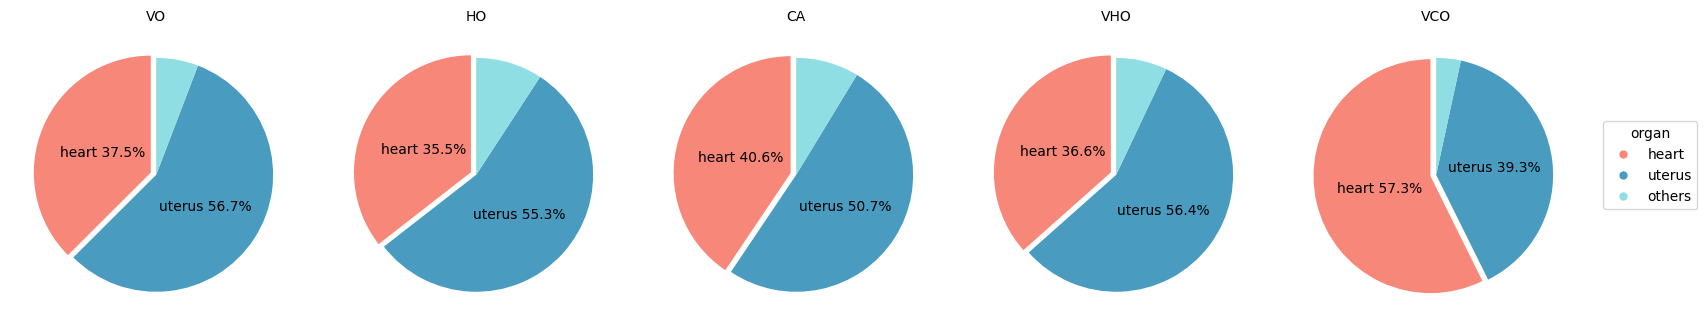

In [39]:
# --- CONFIG ---
min_pct_to_label = 10.0   # show label + leader line only if >= this %
outer_label_offset = 0.5  # how far outside labels sit
donut_width = 1         # 0 for full pie, >0 for donut
colors = {"heart": "#F78779", "uterus": "#499BC0", "others": "#8FDEE3"}
explode = [0.05, 0, 0]

# unified color map for organs (columns)
df = pd.read_csv(f"{WORK_DIR}/label_transfer/HVCA/pred.partial.csv", index_col=0)
organs = list(df.columns)

# layout
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (group, row) in zip(axes, df.iterrows()):
    vals = row.values.astype(float)
    total = vals.sum()
    colseq = [colors[o] for o in organs]

    # draw pie/donut
    wedges, _ = ax.pie(
        vals,
        startangle=90,
        labels=None,                   # no on-slice labels
        colors=colseq,
        wedgeprops=dict(width=donut_width) if donut_width > 0 else None,
        explode=explode
    )

    # label only larger slices, outside with leader lines
    if total > 0:
        for w, v, label in zip(wedges, vals, organs):
            pct = 100.0 * v / total
            if pct >= min_pct_to_label:
                ang = 0.5 * (w.theta2 + w.theta1)
                ang_rad = np.deg2rad(ang)
                x, y = np.cos(ang_rad), np.sin(ang_rad)
                ax.annotate(
                    f'{label} {pct:.1f}%',
                    xy=(x, y),
                    xytext=(outer_label_offset * x, outer_label_offset * y),
                    ha='center', va='center',
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', lw=0)
                )

    ax.set_title(str(group), fontsize=10)
    ax.set_aspect('equal')

# single unified legend (outside)
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=colors[o], markeredgecolor='none', label=o)
    for o in organs
]
fig.legend(handles=legend_handles, title='organ', loc='center left', bbox_to_anchor=(1.0, 0.5))
# fig.suptitle("Organ of EC predicted through PCA-based transfer learning", y=1.03)

# save/show
plt.savefig(f"{WORK_DIR}/label_transfer/HVCA/tl.pca.pie.png", bbox_inches='tight')
plt.savefig(f"{WORK_DIR}/label_transfer/HVCA/tl.pca.pie.svg", bbox_inches='tight')
plt.show()

### 5.1.2 CZI

In [11]:
os.system(f"mkdir -p {WORK_DIR}/label_transfer/CZI")
# os.system(f"ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/CZI/95e4fc1d-c70a-46ea-b459-661c238ddc8e.h5ad {WORK_DIR}/label_transfer/CZI/CZI.h5ad")

0

In [12]:
adata_HVCA = sc.read_h5ad(f"{WORK_DIR}/label_transfer/CZI/CZI.h5ad")
adata_HVCA_EN = adata_HVCA[adata_HVCA.obs["cell_type"] == "endothelial cell"]

In [13]:
sc.pp.filter_cells(adata_HVCA_EN, min_genes=200)
sc.pp.filter_genes(adata_HVCA_EN, min_cells=3)
sc.pp.normalize_total(adata_HVCA_EN, target_sum=1e4)
sc.pp.log1p(adata_HVCA_EN)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


In [21]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [66]:
adata_source = sc.pp.subsample(adata_HVCA_EN, n_obs=10000, random_state=42, copy=True)
adata_target = adata[adata.obs["cell_type"] == "EC"]

adata_target.obs["tissue"] = "Unknown"

/tmp/ipykernel_1909989/685489652.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_target.obs["tissue"] = "Unknown"


In [73]:
# Step 1: Align genes
adata_source.var_names = adata_source.var["feature_name"].astype(str)
keep = ~adata_source.var["feature_name"].duplicated()
adata_source = adata_source[:, keep].copy()
adata_source.var_names = adata_source.var["feature_name"].astype(str)

# Step 1: Align genes
common_genes = adata_source.var_names.intersection(adata_target.var_names)
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

# Step 2: Concatenate for shared processing
adata_combined = ad.concat([adata_source, adata_target], label="dataset", keys=["source", "target"])

# Step 4: Dimensionality reduction (PCA)
n_pcs = 50  # can adjust based on dataset size
svd = TruncatedSVD(n_components=n_pcs)
X_pca = svd.fit_transform(adata_combined.X)

# Step 5: Split PCA embeddings
source_mask = adata_combined.obs["dataset"] == "source"
target_mask = ~source_mask

X_source = X_pca[source_mask]
X_target = X_pca[target_mask]

y_source = adata_combined.obs.loc[source_mask, "tissue"]

# Step 6: Train classifier on source labels
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_source, y_source)

# Step 7: Predict labels for target
predicted_labels = knn.predict(X_target)

# Step 8: Add predictions back to target AnnData
adata_target.obs["tissue_pred"] = predicted_labels

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [81]:
samples = ['ALL','VO','HO','CA','VHO','VCO']

res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_target[adata_target.obs['batch'] == sample]
        res.append(adata_sample.obs['tissue_pred'].value_counts())
        res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

df.to_csv(f"{WORK_DIR}/label_transfer/CZI/pred.csv")

cols_to_keep = ['aorta', 'adipose tissue', 'mammary gland', 'skin of body']
df['others'] = df.drop(columns=cols_to_keep).sum(axis=1)
df = df[['aorta', 'adipose tissue', 'mammary gland', 'skin of body', 'others']]

df.to_csv(f"{WORK_DIR}/label_transfer/CZI/pred.partial.csv")

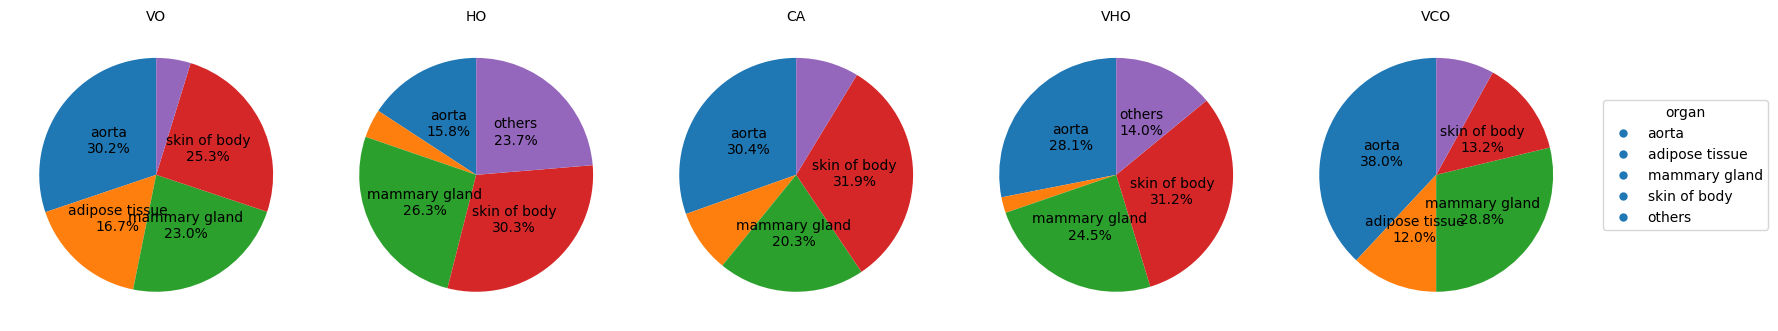

In [83]:
# --- CONFIG ---
min_pct_to_label = 10.0   # show label + leader line only if >= this %
outer_label_offset = 0.5  # how far outside labels sit
donut_width = 1         # 0 for full pie, >0 for donut
# colors = {"heart": "#F78779", "uterus": "#499BC0", "others": "#8FDEE3"}
# explode = [0.05, 0, 0]

# unified color map for organs (columns)
df = pd.read_csv(f"{WORK_DIR}/label_transfer/CZI/pred.partial.csv", index_col=0)
organs = list(df.columns)

# layout
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (group, row) in zip(axes, df.iterrows()):
    vals = row.values.astype(float)
    total = vals.sum()
    # colseq = [colors[o] for o in organs]

    # draw pie/donut
    wedges, _ = ax.pie(
        vals,
        startangle=90,
        labels=None,                   # no on-slice labels
        # colors=colseq,
        wedgeprops=dict(width=donut_width) if donut_width > 0 else None,
        # explode=explode
    )

    # label only larger slices, outside with leader lines
    if total > 0:
        for w, v, label in zip(wedges, vals, organs):
            pct = 100.0 * v / total
            if pct >= min_pct_to_label:
                ang = 0.5 * (w.theta2 + w.theta1)
                ang_rad = np.deg2rad(ang)
                x, y = np.cos(ang_rad), np.sin(ang_rad)
                ax.annotate(
                    f'{label}\n{pct:.1f}%',
                    xy=(x, y),
                    xytext=(outer_label_offset * x, outer_label_offset * y),
                    ha='center', va='center',
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', lw=0)
                )

    ax.set_title(str(group), fontsize=10)
    ax.set_aspect('equal')

# single unified legend (outside)
legend_handles = [
    plt.Line2D([0], 
               [0], 
               marker='o', 
               linestyle='',
               # markerfacecolor=colors[o], 
               markeredgecolor='none', 
               label=o)
    for o in organs
]
fig.legend(handles=legend_handles, title='organ', loc='center left', bbox_to_anchor=(1.0, 0.5))
# fig.suptitle("Organ of EC predicted through PCA-based transfer learning", y=1.03)

# save/show
plt.savefig(f"{WORK_DIR}/label_transfer/CZI/tl.pca.pie.png", bbox_inches='tight')
plt.savefig(f"{WORK_DIR}/label_transfer/CZI/tl.pca.pie.svg", bbox_inches='tight')
plt.show()

## 5.2 CM

In [9]:
adata = sc.read_h5ad(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/GSE216019_Adult_Foetal_Integrated_Hearts_VKS2022.h5ad")
# adata = adata[adata.obs["cell_type"] == "Atrial_Cardiomyocyte"]
adata_source = sc.pp.subsample(adata, n_obs=1000, random_state=42, copy=True)
# adata_source = adata

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [10]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")
adata_target = adata[adata.obs["cell_type"] == "CM"]
adata_target.obs["stage"] = "Unknown"

/tmp/ipykernel_1543503/1292538138.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_target.obs["stage"] = "Unknown"


In [11]:
common_genes = adata_source.var_names.intersection(adata_target.var_names)
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

In [14]:
adata_target

AnnData object with n_obs × n_vars = 25229 × 2805
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'batch', 'leiden', 'doublet_score', 'predicted_doublet', 'cell_type', 'cell_type_subcluster', 'cpdb_group', 'stage'
    obsm: 'X_pca', 'X_umap'

In [15]:
adata_source.obsm.clear()

In [18]:
sc.pp.pca(adata_source, n_comps=50)
sc.pp.neighbors(adata_source)
sc.tl.umap(adata_source)
sc.tl.ingest(adata_target, adata_source, obs='stage')
adata_target.obs['stage']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


AAACCCAAGAAGGGAT-1-0    foetal
AAACCCAAGTCAGGGT-1-0    foetal
AAACCCACATCCAACA-1-0    foetal
AAACCCAGTAGATGTA-1-0    foetal
AAACCCAGTAGTACGG-1-0    foetal
                         ...  
TTTGTTGAGACTGGGT-1-4    foetal
TTTGTTGAGATTGACA-1-4    foetal
TTTGTTGAGGGTACGT-1-4    foetal
TTTGTTGTCATGCCGG-1-4    foetal
TTTGTTGTCGTTGCCT-1-4    foetal
Name: stage, Length: 25229, dtype: category
Categories (2, object): ['adult', 'foetal']

In [22]:
samples = ['ALL','HO','CA','VHO','VCO']

res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_target[adata_target.obs['batch'] == sample]
        res.append(adata_sample.obs['stage'].value_counts())
        res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

df.to_csv(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/pred.csv")

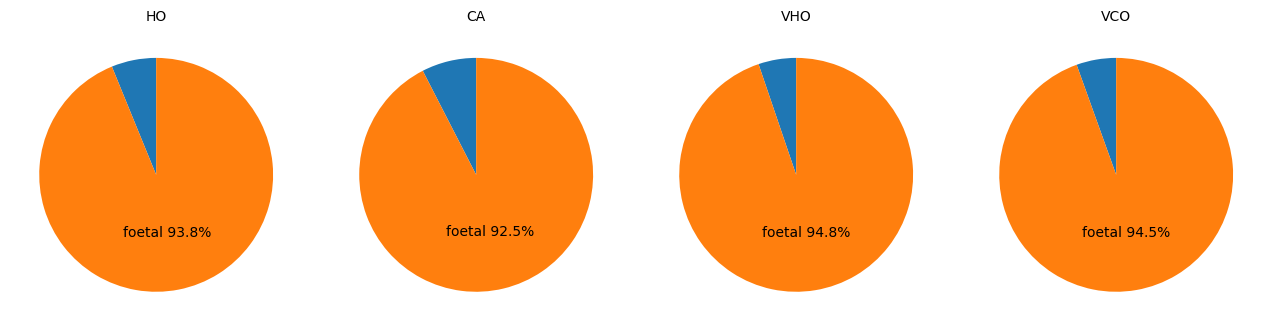

In [25]:
# --- CONFIG ---
min_pct_to_label = 10.0   # show label + leader line only if >= this %
outer_label_offset = 0.5  # how far outside labels sit
donut_width = 1         # 0 for full pie, >0 for donut
colors = {"heart": "#F78779", "uterus": "#499BC0", "others": "#8FDEE3"}
explode = [0, 0]

# unified color map for organs (columns)
df = pd.read_csv(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/pred.csv", index_col=0)
organs = list(df.columns)

# layout
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (group, row) in zip(axes, df.iterrows()):
    vals = row.values.astype(float)
    total = vals.sum()
    # colseq = [colors[o] for o in organs]

    # draw pie/donut
    wedges, _ = ax.pie(
        vals,
        startangle=90,
        labels=None,                   # no on-slice labels
        # colors=colseq,
        wedgeprops=dict(width=donut_width) if donut_width > 0 else None,
        explode=explode
    )

    # label only larger slices, outside with leader lines
    if total > 0:
        for w, v, label in zip(wedges, vals, organs):
            pct = 100.0 * v / total
            if pct >= min_pct_to_label:
                ang = 0.5 * (w.theta2 + w.theta1)
                ang_rad = np.deg2rad(ang)
                x, y = np.cos(ang_rad), np.sin(ang_rad)
                ax.annotate(
                    f'{label} {pct:.1f}%',
                    xy=(x, y),
                    xytext=(outer_label_offset * x, outer_label_offset * y),
                    ha='center', va='center',
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', lw=0)
                )

    ax.set_title(str(group), fontsize=10)
    ax.set_aspect('equal')

# single unified legend (outside)
# legend_handles = [
#     plt.Line2D([0], [0], marker='o', linestyle='',
#                markerfacecolor=colors[o], markeredgecolor='none', label=o)
#     for o in organs
# ]
# fig.legend(handles=legend_handles, title='organ', loc='center left', bbox_to_anchor=(1.0, 0.5))
# fig.suptitle("Organ of EC predicted through PCA-based transfer learning", y=1.03)

# save/show
plt.savefig(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/tl.pca.pie.png", bbox_inches='tight')
plt.savefig(f"{WORK_DIR}/label_transfer/heart_cell_atlas_v2/tl.pca.pie.svg", bbox_inches='tight')
plt.show()

# 6. CellphoneDB

In [1]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [2]:
base_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO08"

cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
work_dir  = f"{base_dir}/cpdb"
data_dir  = f"{base_dir}/cpdb/adata"
processed_dir = f"{base_dir}/cpdb/processed"
figs_dir = f"{base_dir}/cpdb/figs"

## 6.1 prepare data

In [3]:
adata_full = sc.read_h5ad(f"{base_dir}/adata/sample_recollect/ALL.h5ad")

cpdb_group_map = {
    "cpdb_group_1": {'CM':'CM', 'EC':'EC', 'EP':'EP', 'FB':'FB', 'PR':'PR', 'SM':'SM', 'UN':'UN'}, 
    "cpdb_group_2": {'CM':'CM', 'EC':'EC', 'EP':'EP', 'FB':'PV', 'PR':'PV', 'SM':'SM', 'UN':'UN'}, 
    "cpdb_group_3": {'CM':'CM', 'EC':'EC', 'EP':'EP', 'FB':'PV', 'PR':'PV', 'SM':'PV', 'UN':'UN'},
}

for cpdb_group_id in ("cpdb_group_1", "cpdb_group_2", "cpdb_group_3"):
    adata_full.obs[cpdb_group_id] = adata_full.obs['cpdb_group'].copy()
    adata_full.obs[cpdb_group_id] = adata_full.obs[cpdb_group_id].map(cpdb_group_map[cpdb_group_id])
    adata_full.obs[cpdb_group_id] = adata_full.obs[cpdb_group_id].astype('category')
    
sc.pp.highly_variable_genes(adata_full, n_top_genes=4000)

for batch in adata_full.obs["batch"].unique():
    adata_full[adata_full.obs['batch'] == batch].write(f"{work_dir}/adata/{batch}.h5ad")

## 6.2 run CPDB

In [10]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob.glob(pattern):
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    for cpdb_group_id in ("cpdb_group_1", "cpdb_group_2", "cpdb_group_3"):
        os.system(f"mkdir -p {work_dir}/{cpdb_group_id}")
        
        metadata_df = pd.DataFrame({
            "barcode_sample" : adata.obs_names,
            "cell_type"      : adata.obs[cpdb_group_id].to_list()
        })

        metadata_df.index = np.arange(metadata_df.shape[0])
        metadata_path     = f"{work_dir}/{cpdb_group_id}/{label}.statistical.metadata.tsv"
        metadata_df.to_csv(metadata_path,index=False,sep="\t")
        out_dir      = f"{work_dir}/{cpdb_group_id}/{label}.statistical"

        # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
        cpdb_results = cpdb_statistical_analysis_method.call(
            cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
            meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
            counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
            counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
            score_interactions = True,              # optional: whether to score interactions or not. 
            output_path        = out_dir,           # Path to save results
            pvalue             = 0.05
        )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/adata/VHO.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/processed/VHO.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/VHO.statistical.metadata.tsv
[ ][CORE][03/03/26-03:25:06][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][03/03/26-03:25:06][INFO] Running Real Analysis
[ ][CORE][03/03/26-03:25:06][INFO] Running Statistical Analysis


100%|████████████████████████████████████████| 1000/1000 [00:21<00:00, 45.92it/s]

[ ][CORE][03/03/26-03:25:28][INFO] Building Pvalues result
[ ][CORE][03/03/26-03:25:28][INFO] Building results


[ ][CORE][03/03/26-03:25:28][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████| 7/7 [00:00<00:00, 108.64it/s]

...

[ ][CORE][03/03/26-03:30:22][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 462.62it/s]


[ ][CORE][03/03/26-03:30:22][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|███████████████████████████████████████████| 25/25 [00:00<00:00, 106.74it/s]


Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_deconvoluted_03_03_2026_033023.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_deconvoluted_percents_03_03_2026_033023.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_means_03_03_2026_033023.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_pvalues_03_03_2026_033023.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_significant_means_03_03_2026_033023.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/VCO.statistical/statistical_analysis_inter

In [11]:
for cpdb_group_id in ("cpdb_group_1", "cpdb_group_2", "cpdb_group_3"):
    
    pattern = os.path.join(work_dir, cpdb_group_id, "*.statistical")
    date = "03_03_2026"
    for cpdb_dir in glob.glob(pattern):
        label = os.path.basename(cpdb_dir).replace(".statistical","")
        means_path         = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_means_{date}_*.txt"))[0]
        pvals_path         = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_pvalues_{date}_*.txt"))[0]
        deconvolution_path = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
        interaction_path   = glob.glob(os.path.join(cpdb_dir, f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

        means_df         = pd.read_csv(means_path,sep="\t")
        pvals_df         = pd.read_csv(pvals_path,sep="\t")
        deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
        interaction_df   = pd.read_csv(interaction_path,sep="\t")

        adata_path = os.path.join(data_dir,f"{label}.h5ad")
        adata      = ad.read_h5ad(adata_path)
        adata.obs["cpdb_key"] = adata.obs[cpdb_group_id]
        # adata.obs["cpdb_key"] = adata.obs["cell_type"]

        for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
            df = kpy.plot_cpdb(
                adata=adata,
                cell_type1=cpdb_key,
                cell_type2=".",
                means=means_df,
                pvals=pvals_df,
                celltype_key="cpdb_key",
                highlight_size=1,
                figsize=(24,24),
                title=f"{label} {cpdb_key}",
                default_style=False,
                return_table=True
            )
            df.index = [index.replace(">@<","-") for index in df.index]
            df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
            df["significant"] = df["significant"].fillna("no")
            df_path = os.path.join(cpdb_dir, f"{label}__{cpdb_key}.csv")
            df.to_csv(df_path)

VHO: 100%|█████████████████████████████████████████| 5/5 [00:00<00:00,  8.21it/s]


In [17]:
# import os, re
# import pandas as pd
# from collections import Counter, defaultdict

# alpha = 0.05  # significance cutoff
# pair_col_pat = re.compile(r"(.+)\|(.+)")  # CPDB pvals col pattern "A|B"

# def extract_pair_columns(df, keep_celltypes):
#     """Return list of pvalue columns that look like 'A|B' and both A,B in keep_celltypes."""
#     cols = []
#     for c in df.columns:
#         m = pair_col_pat.fullmatch(c)
#         if m:
#             A, B = m.group(1), m.group(2)
#             if (A in keep_celltypes) and (B in keep_celltypes):
#                 cols.append((c, A, B))
#     return cols

# def count_sig_per_pair(pvals_df, keep_celltypes, alpha=0.05):
#     """Count significant interactions per directed pair (A,B)."""
#     out = defaultdict(int)
#     pair_cols = extract_pair_columns(pvals_df, keep_celltypes)
#     for c, A, B in pair_cols:
#         # Each row is one interacting_pair; count how many are significant for this A|B column
#         out[(A, B)] = int((pvals_df[c] < alpha).sum())
#     return out

# # ---- main: iterate runs and collect counts ----
# counts_by_run = {}                       # label -> {(A,B): count}
# all_pairs = set()                        # union of all (A,B) seen
# work_dir = work_dir                      # assumes you already defined this
# date = date                              # assumes you already defined this
# pattern = os.path.join(work_dir,"*.statistical")

# for cpdb_dir in glob.glob(pattern):
#     label = os.path.basename(cpdb_dir).replace(".statistical","")
#     means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
#     pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
#     decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
#     adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

#     # use your existing cts list; if you prefer to derive from adata:
#     cts = sorted(adata.obs['cpdb_group'].unique())

#     pair_counts = count_sig_per_pair(pvals_df, cts, alpha=alpha)
#     counts_by_run[label] = pair_counts
#     all_pairs.update(pair_counts.keys())

# # ---- assemble a comparison table: rows=(A,B), columns=runs ----
# all_pairs = sorted(all_pairs)  # stable order
# summary_df = pd.DataFrame(
#     index=pd.MultiIndex.from_tuples(all_pairs, names=["celltype_A", "celltype_B"]),
#     columns=sorted(counts_by_run.keys()),
#     data=0
# )
# for label, pc in counts_by_run.items():
#     for k, v in pc.items():
#         summary_df.loc[k, label] = v

# # Optional: add totals per run and per (A,B)
# summary_df["MAX_across_runs"] = summary_df.max(axis=1)
# run_totals = summary_df.drop(columns=["MAX_across_runs"]).sum(axis=0).to_frame(name="TOTAL_significant_pairs")
# global_max = int(summary_df["MAX_across_runs"].max())

# print("Global maximum significant links for any (A,B):", global_max)
# print("\nTotals per run (sum of all (A,B) significant links):")
# print(run_totals.sort_values("TOTAL_significant_pairs", ascending=False))

# # ---- N_max for padding step (per directed pair) ----
# # Dictionary you can pass to your padding routine:
# N_max = {pair: int(max(summary_df.loc[pair, summary_df.columns != "MAX_across_runs"])) for pair in all_pairs}

# # Example: inspect a few pairs
# print("\nExample (first 10 pairs) N_max values:")
# for pair in list(all_pairs)[:10]:
#     print(pair, "->", N_max[pair])


# def pad_cpdb_links_for_fixed_width(decon_df, pvals_df, keep_celltypes, alpha=0.05, pair_col="interacting_pair",
#                                    ctA_col="partner_a", ctB_col="partner_b"):
#     # 1) count significant interactions per A->B for this run
#     sig = pvals_df[pvals_df['pvalue'] < alpha]
#     # assuming pvals_df has columns with celltype pairs already melted; adjust if needed
#     # build (A,B) -> list of interacting pairs present
#     AB_to_pairs = defaultdict(list)
#     for _, r in sig.iterrows():
#         A, B = r[ctA_col], r[ctB_col]
#         if (A in keep_celltypes) and (B in keep_celltypes):
#             AB_to_pairs[(A,B)].append(r[pair_col])

#     # 2) compute maximums across *all runs* beforehand, pass in as N_max dict
#     # here we assume you precomputed: N_max[(A,B)] = max_count
#     # (you’d compute this by scanning all runs’ AB_to_pairs first)
#     # ---- fill this from outside ----
#     # raise NotImplementedError("Precompute N_max[(A,B)] from all runs and inject it here.")

#     # 3) create padding rows for missing counts
#     pad_rows = []
#     for (A,B), pairs in AB_to_pairs.items():
#         need = N_max[(A,B)] - len(pairs)
#         for i in range(need):
#             pad_rows.append({
#                 ctA_col: A, ctB_col: B,
#                 pair_col: "__PAD__",
#                 # include any other columns that ktplotspy expects from decon_df
#             })

#     if pad_rows:
#         import pandas as pd
#         decon_df = pd.concat([decon_df, pd.DataFrame(pad_rows)], ignore_index=True)
#     return decon_df

In [13]:
from plotnine import scale_color_identity, scale_fill_identity
from plotnine import scale_color_manual

for cpdb_group_id in ("cpdb_group_1", "cpdb_group_2", "cpdb_group_3"):
    os.system(f"mkdir -p {work_dir}/{cpdb_group_id}/fig")
    
    pattern = os.path.join(work_dir, cpdb_group_id, "*.statistical")
    for cpdb_dir in glob.glob(pattern):
        print(cpdb_dir)
        label = os.path.basename(cpdb_dir).replace(".statistical","")
        means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
        pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
        decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
        adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

        out = kpy.plot_cpdb_heatmap(
            pvals=pvals_df,
            symmetrical=False,
            return_tables=True
        )

        g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
        g.ax_col_dendrogram.remove()
        g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
        fig_path = f"{work_dir}/{cpdb_group_id}/fig/{label}.n_signif_interactions_heatmap.png"
        plt.savefig(fig_path,dpi=100)
        plt.close()

        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=".",
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key=cpdb_group_id,
            highlight_size=1,
            figsize=(6,6),
            title=f"{label}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df = df[df["significant"] == "yes"]
        df_path = f"{work_dir}/{cpdb_group_id}/fig/{label}.csv"
        df.to_csv(df_path)

        p = kpy.plot_cpdb(
            adata=adata,
            cell_type1=".",
            cell_type2=".",
            keep_significant_only=True,
            means=means_df,
            pvals=pvals_df,
            celltype_key=cpdb_group_id,
            figsize=(20, 8),
            title=f"{label}: active interactions",
            return_table=False
        )
        p.save(f"{work_dir}/{cpdb_group_id}/fig/{label}.dotplot.png")

        cts = adata.obs[cpdb_group_id].unique().to_list()
        cts.remove("UN")
        # if np.nan in cts:
        #     cts.remove(np.nan)

        sector_colors = {
            "CM": (60/255, 170/255, 60/255),
            "EC": (230/255, 80/255, 160/255),
            "EP": (60/255, 180/255, 220/255),
            "PR": (255/255, 235/255, 125/255),
            "FB": (240/255, 180/255, 20/255),
            "SM": (220/255, 160/255, 30/255),
            "UN": (190/255, 190/255, 190/255),
            "OTH": (170/255, 170/255, 170/255),
        }

        p = kpy.plot_cpdb_chord(
            adata=adata[adata.obs[cpdb_group_id] != "UN"],
            cell_type1='.',
            cell_type2='.',
            keep_celltypes=cts,
            means=means_df,
            pvals=pvals_df,
            deconvoluted=decon_df,
            celltype_key=cpdb_group_id,
            link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
            sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
            legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
            link_offset=1,
            sector_colors=sector_colors
        )

        plt.savefig(f"{work_dir}/{cpdb_group_id}/fig/{label}.chordplot.png")
        plt.close()

#         if label not in ["VO", "CA"]:
#             p = kpy.plot_cpdb_chord(
#                 adata=adata[adata.obs[cpdb_group_id] != "UN"],
#                 cell_type1='EC',
#                 cell_type2='CM',
#                 keep_celltypes=cts,
#                 means=means_df,
#                 pvals=pvals_df,
#                 deconvoluted=decon_df,
#                 celltype_key=cpdb_group_id,
#                 link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
#                 sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
#                 legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
#                 # legend_kwargs={},
#                 link_offset=1,
#                 sector_colors=sector_colors
#             )

#             plt.savefig(f"{figs_dir}/{label}.chordplot.EC_CM.png")
#             plt.close()

#         if True:
#             p = kpy.plot_cpdb_chord(
#                 adata=adata[adata.obs[cpdb_group_id] != "UN"],
#                 cell_type1='.',
#                 cell_type2='.',
#                 keep_celltypes=cts,
#                 means=means_df,
#                 pvals=pvals_df,
#                 deconvoluted=decon_df,
#                 celltype_key=cpdb_group_id,
#                 interaction=["VEGFA"],
#                 link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
#                 sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
#                 legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 10},
#                 link_offset=1,
#                 sector_colors=sector_colors
#             )

#             plt.savefig(f"{figs_dir}/{label}.chordplot.VEGFA.png")
#             plt.close()

/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/CA.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/VHO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/VO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_1/VCO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_2/HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_2/VCO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_2/VHO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_2/CA.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_2/VO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO08/cpdb/cpdb_group_3/HO.statist

In [24]:
batch1 = "VO"
batch2 = "VCO"

pvals_df_vo = pd.read_csv(glob.glob(f"{work_dir}/{batch1}.statistical/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t', index_col=1).iloc[:,12:]
pvals_df_vco = pd.read_csv(glob.glob(f"{work_dir}/{batch2}.statistical/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t', index_col=1).iloc[:,12:]

f_vo = f"{work_dir}/extracted/{batch1}.unique_to_{batch2}.csv"
f_vco = f"{work_dir}/extracted/{batch2}.unique_to_{batch1}.csv"
f_both = f"{work_dir}/extracted/{batch1}_{batch2}_shared.csv"

shared_col = list(pvals_df_vo.columns.intersection(pvals_df_vco.columns))
shared_col = [e for e in shared_col if "UN" not in e]

vco_unique_col = []
adata_vo = sc.read_h5ad(f"{work_dir}/adata/{batch1}.h5ad")
adata_vco = sc.read_h5ad(f"{work_dir}/adata/{batch2}.h5ad")
vo_ct = set(adata_vo.obs["cpdb_group"].unique().to_list())
vco_ct = set(adata_vco.obs["cpdb_group"].unique().to_list())
for c in pvals_df_vco.columns:
    if "UN" in c:
        continue
    ct1, ct2 = c.split("|")
    if (ct1 in vo_ct) and (ct2 in vo_ct):
        continue
    elif ct1 in vo_ct:
        vco_unique_col.append(c)
    elif ct2 in vo_ct:
        vco_unique_col.append(c)

shared_row = list(pvals_df_vo.index.intersection(pvals_df_vco.index))

with open(f_vo, "w") as f:
    f.write("")
with open(f_vco, "w") as f:
    f.write("")
with open(f_both, "w") as f:
    f.write("")

for r in pvals_df_vo.index:
    for c in shared_col:
        if pvals_df_vo.loc[r,c] < 0.05:
            if r not in shared_row:
                with open(f_vo, "a") as f:
                    f.write(f"{r},{c}\n")
            elif pvals_df_vco.loc[r,c] > 0.05:
                with open(f_vo, "a") as f:
                    f.write(f"{r},{c}\n")
            else:
                with open(f_both, "a") as f:
                    f.write(f"{r},{c}\n")

for r in pvals_df_vco.index:
    for c in shared_col:
        if pvals_df_vco.loc[r,c] < 0.05:
            if r not in shared_row:
                with open(f_vco, "a") as f:
                    f.write(f"{r},{c}\n")
            elif pvals_df_vo.loc[r,c] > 0.05:
                with open(f_vco, "a") as f:
                    f.write(f"{r},{c}\n")
    for c in vco_unique_col:
        if pvals_df_vco.loc[r,c] < 0.05:
            with open(f_vco, "a") as f:
                f.write(f"{r},{c}\n")

In [30]:
batch1 = "HO"
batch2 = "VCO"

pvals_df_vo = pd.read_csv(glob.glob(f"{work_dir}/{batch1}.statistical/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t', index_col=1).iloc[:,12:]
pvals_df_vco = pd.read_csv(glob.glob(f"{work_dir}/{batch2}.statistical/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t', index_col=1).iloc[:,12:]

f_vo = f"{work_dir}/extracted/{batch1}.unique_to_{batch2}.csv"
f_vco = f"{work_dir}/extracted/{batch2}.unique_to_{batch1}.csv"
f_both = f"{work_dir}/extracted/{batch1}_{batch2}_shared.csv"

shared_col = list(pvals_df_vo.columns.intersection(pvals_df_vco.columns))
shared_col = [e for e in shared_col if "UN" not in e]

vco_unique_col = []
adata_vo = sc.read_h5ad(f"{work_dir}/adata/{batch1}.h5ad")
adata_vco = sc.read_h5ad(f"{work_dir}/adata/{batch2}.h5ad")
vo_ct = set(adata_vo.obs["cpdb_group"].unique().to_list())
vco_ct = set(adata_vco.obs["cpdb_group"].unique().to_list())
for c in pvals_df_vco.columns:
    if "UN" in c:
        continue
    ct1, ct2 = c.split("|")
    if (ct1 in vo_ct) and (ct2 in vo_ct):
        continue
    elif ct1 in vo_ct:
        vco_unique_col.append(c)
    elif ct2 in vo_ct:
        vco_unique_col.append(c)

shared_row = list(pvals_df_vo.index.intersection(pvals_df_vco.index))

with open(f_vo, "w") as f:
    f.write("")
with open(f_vco, "w") as f:
    f.write("")
with open(f_both, "w") as f:
    f.write("")

for r in pvals_df_vo.index:
    for c in shared_col:
        if pvals_df_vo.loc[r,c] < 0.05:
            if r not in shared_row:
                with open(f_vo, "a") as f:
                    f.write(f"{r},{c}\n")
            elif pvals_df_vco.loc[r,c] > 0.05:
                with open(f_vo, "a") as f:
                    f.write(f"{r},{c}\n")
            else:
                with open(f_both, "a") as f:
                    f.write(f"{r},{c}\n")

for r in pvals_df_vco.index:
    for c in shared_col:
        if pvals_df_vco.loc[r,c] < 0.05:
            if r not in shared_row:
                with open(f_vco, "a") as f:
                    f.write(f"{r},{c}\n")
            elif pvals_df_vo.loc[r,c] > 0.05:
                with open(f_vco, "a") as f:
                    f.write(f"{r},{c}\n")
    for c in vco_unique_col:
        if pvals_df_vco.loc[r,c] < 0.05:
            with open(f_vco, "a") as f:
                f.write(f"{r},{c}\n")

# 7. Data: 20251211

In [6]:
DATA_DIR = "/home/herbert/PyProjects/cocultured_organ/data/251211"

## 7.1 pp

In [7]:
os.system(f"mkdir -p {WORK_DIR}/adata/new_data")
os.system(f"mkdir -p {WORK_DIR}/adata/new_data/raw")
os.system(f"mkdir -p {WORK_DIR}/adata/new_data/processed")

0

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


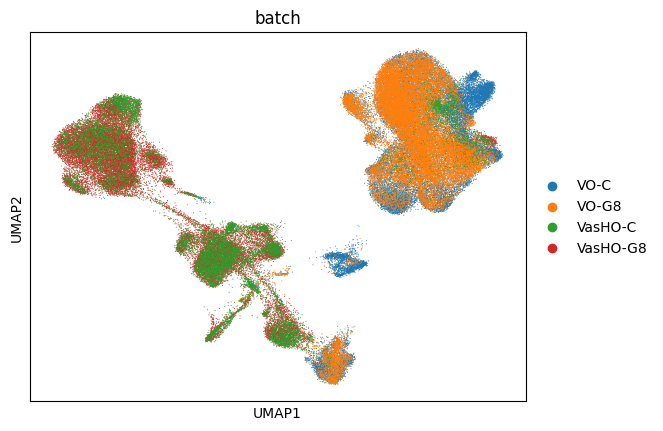

In [9]:
adata_complete = None

for f1 in glob.glob(f"{WORK_DIR}/adata/new_data/raw/*.h5ad"):
    batch = f1.split("/")[-1].strip(".h5ad")
    adata = sc.read_h5ad(f1)
    adata.obs["batch"] = batch

    if adata_complete is None:
        adata_complete = adata
    else:
        adata_complete = ad.concat([adata_complete, adata], merge="same")

adata = adata_complete
adata.obs_names_make_unique()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="batch")
sc.tl.pca(adata, svd_solver='arpack', n_comps=50, random_state=42)
sc.pp.neighbors(adata, n_pcs=50, n_neighbors=1000, random_state=42)
sc.tl.leiden(adata, random_state=42)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="batch",
    size=2,
)

In [11]:
for batch in adata.obs["batch"].unique():
    adata[adata.obs["batch"] == batch].write(f"{WORK_DIR}/adata/new_data/processed/{batch}.h5ad")
adata.write(f"{WORK_DIR}/adata/new_data/processed/ALL.h5ad")

## 7.2

In [7]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/new_data/processed/ALL.h5ad")

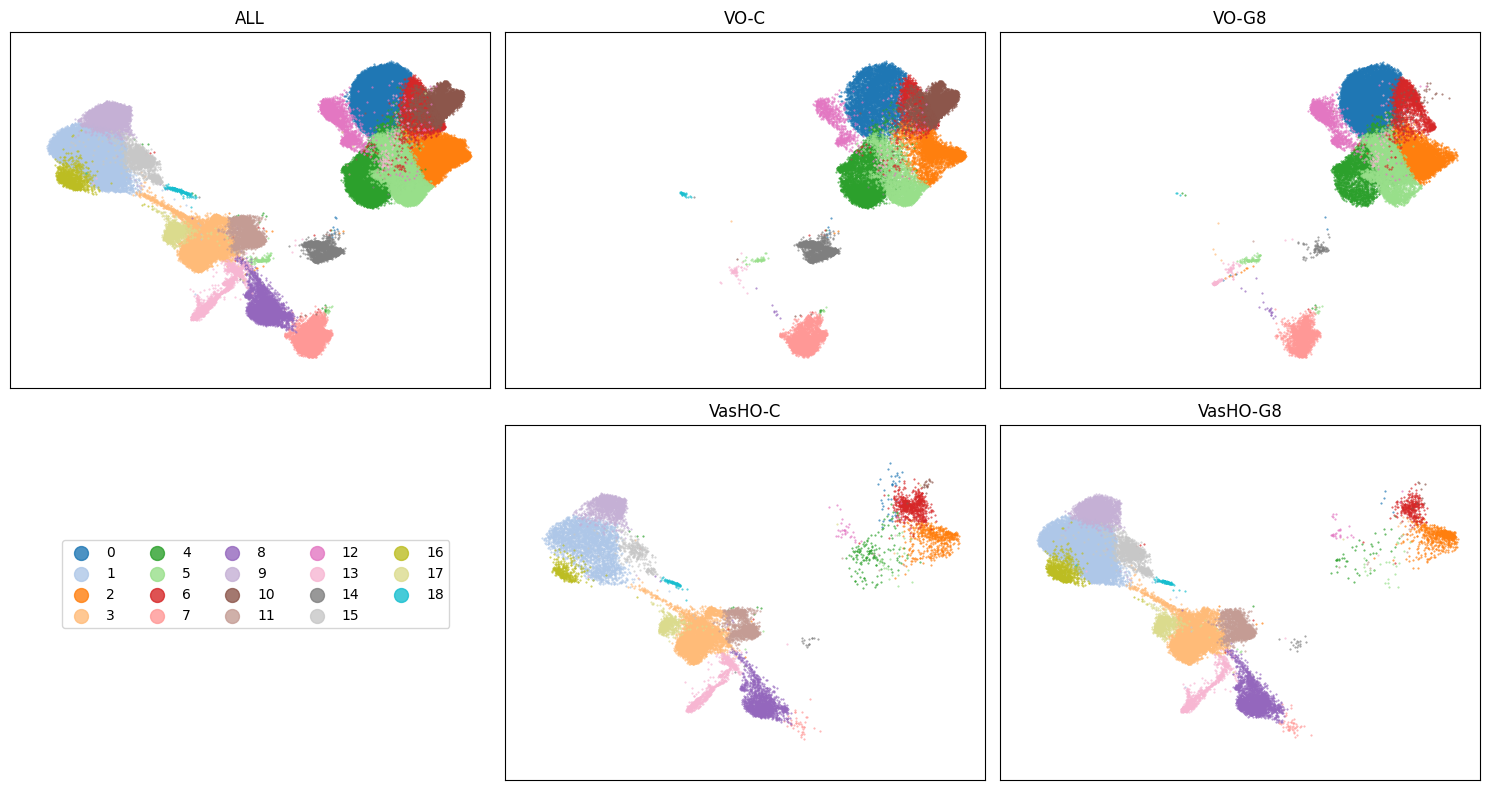

In [8]:
groups = ("ALL", "VO-C", "VO-G8", "VasHO-C", "VasHO-G8")

tab20_rgb = [(r, g, b, 0.8) for r, g, b in plt.cm.tab20.colors]

fig, axs = plt.subplots(2, 3, figsize=(15,8))
axs = axs.flatten()
axs_new = [axs[0], axs[1], axs[2], axs[4], axs[5]]
fig.delaxes(axs[3])

handles = []
labels = []


xmin = -9
xmax = 19
ymin = -8
ymax = 18

for i, group in enumerate(groups):
    ax = axs_new[i]
    if group == "ALL":
        adata_sub = adata
    else:
        adata_sub = adata[adata.obs["batch"] == group]

    for j in adata.obs["leiden"].unique().sort_values():
        sc_plot = ax.scatter(
            adata_sub[adata_sub.obs["leiden"] == j].obsm["X_umap"][:,0],
            adata_sub[adata_sub.obs["leiden"] == j].obsm["X_umap"][:,1],
            s=0.25,
            label=int(j),
            color=tab20_rgb[int(j)]
        )
        if i == 0:
            handles.append(sc_plot)
            labels.append(j)
    
    ax.set_title(group)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, labels,
    loc='lower left',
    ncol=5,
    markerscale=20,
    bbox_to_anchor=(0.04, 0.2)
)

plt.tight_layout()
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


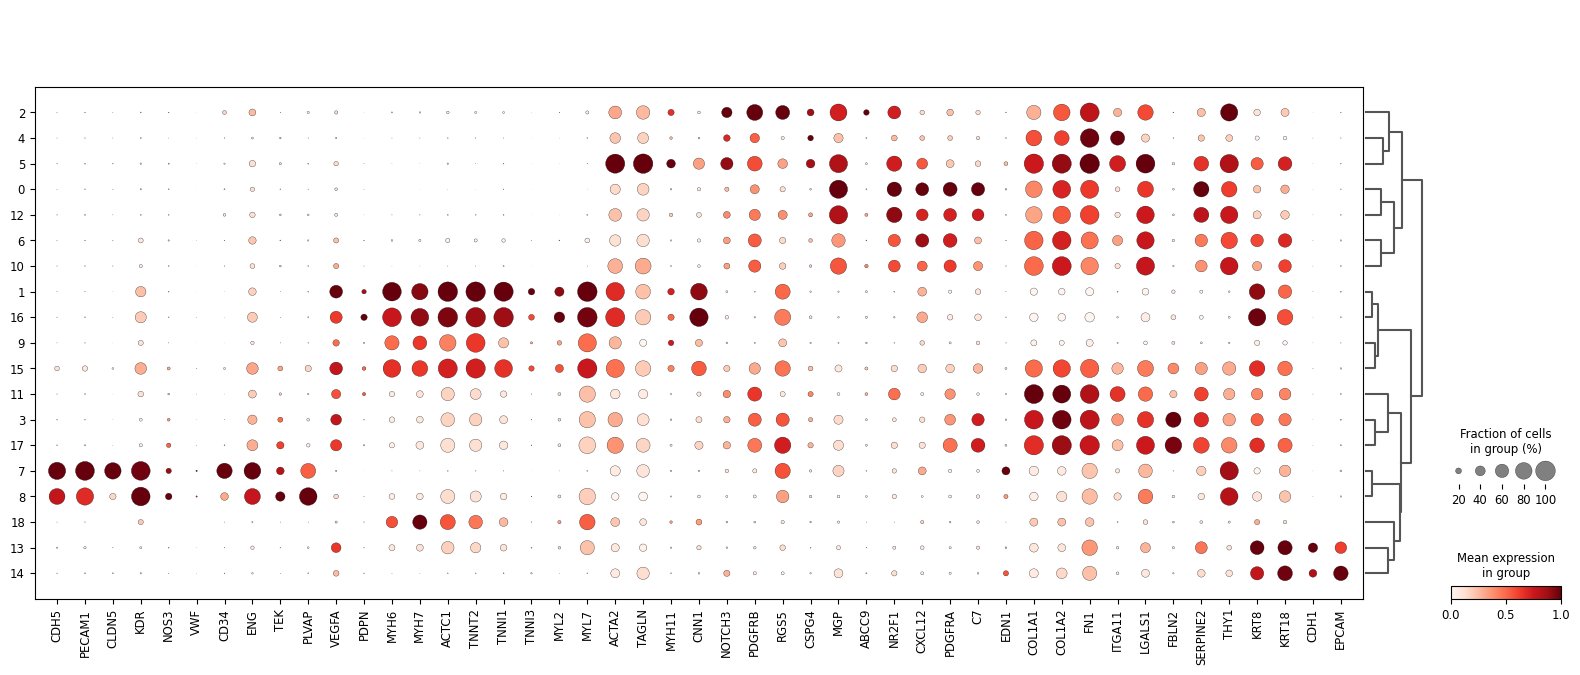

In [9]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

sc.pl.dotplot(adata, 
              marker_dict, 
              groupby="leiden", 
              standard_scale="var", 
              show=True, dendrogram=True)

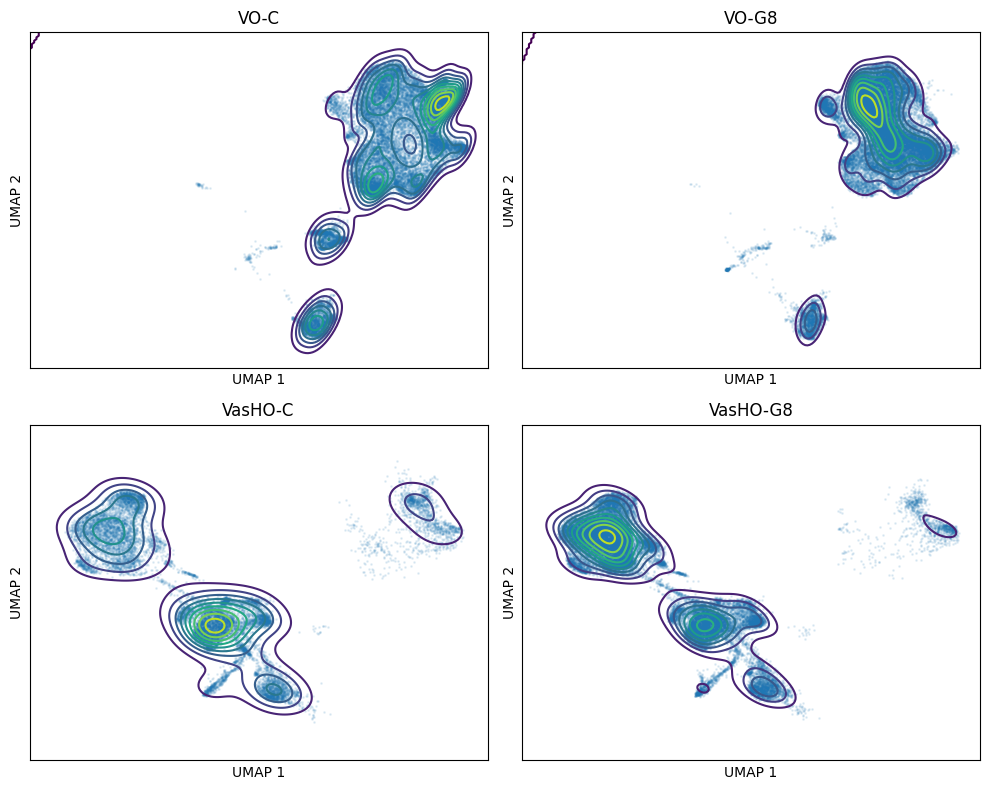

In [10]:
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(2, 2, figsize=(10,8))
axs = axs.flatten()

xmin = -9
xmax = 19
ymin = -8
ymax = 18

for i, batch in enumerate(adata.obs["batch"].unique().sort_values()):
    x = adata[adata.obs["batch"] == batch].obsm["X_umap"][:,0]
    y = adata[adata.obs["batch"] == batch].obsm["X_umap"][:,1]
    
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, 200),
        np.linspace(ymin, ymax, 200)
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    axs[i].scatter(x, y, s=1, alpha=0.1)
    axs[i].contour(xx, yy, zz, levels=10)
    
    axs[i].set_title(batch)
    axs[i].set_xlim(xmin, xmax)
    axs[i].set_ylim(ymin, ymax)
    axs[i].set_xlabel("UMAP 1")
    axs[i].set_ylabel("UMAP 2")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.tight_layout()
plt.show()